**Modern Data Architectures for Big Data II - Group Assignment**\
**Section 1 Group 5**

## **Apple Sales Analysis**

This workbook contains analysis from 2 main datasets:
- **Apple Global Product Sales (2022 to 2024):** https://www.kaggle.com/datasets/ashyou09/apple-global-product-sales-dataset
- **World Population Data (2025):** https://github.com/sharmadhiraj/free-json-datasets/blob/master/docs/demographics-population/world_population_by_country.json

**The objective of this analysis is to identify targeted strategies that can help improve Apple's global sales performance**

The following **<u>business questions** help to guide the analysis:\
**1. Which Apple products should be prioritised to drive revenue?**\
**2. What sales channel strategy is more effective across different markets?**\
**3. Which markets present greater growth opportunities for Apple?**

Through addressing these business questions, 3 concrete recommendations are then identified to support Apple in achieving improved sales performance, market expansion and sustainable growth.

This notebook consists of the following sections:
1. Notebook environment setup and Initiating Spark
2. Data cleaning & manipulation
3. Analysing Apple dataset
4. Combining both dataframes to form a new dataframe
5. Analysing combined dataframe
6. Building the Machine Learning Model - Option 1: Linear Regresion
7. Building the Machine Learning Model - Option 2: Random Forest
8. Comparing Machine Learning Models - Linear Regression vs Random Forest
9. Combining all analyses
10. Conclusion: Connecting all the dots

## **1. Notebook environment setup and Initiating Spark**

In [1]:
# Initiating Spark
from pyspark.sql.session import SparkSession

spark_session = \
  SparkSession.builder\
              .appName("apple_sales_analysis")\
              .getOrCreate()

print(f"This cluster relies on Spark '{spark_session.version}'")

26/03/19 21:02:41 WARN Utils: Your hostname, osbdet resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s1)
26/03/19 21:02:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 21:02:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


This cluster relies on Spark '3.5.4'


In [2]:
import pyspark.sql.functions as F
import pyspark.sql.types as T

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.access.key", "s3access")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.secret.key", "_s3access123$")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.path.style.access", "true")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.endpoint", "http://localhost:9000")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.connection.ssl.enabled", "false")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")

In [5]:
IngestDate = "2026-03-19"

In [6]:
# Load Apple sales data
df_apple = spark_session.read \
    .option("multiLine", "true") \
    .json(f"s3a://apple-sales-processed/curated/apple_sales/ingest_date={IngestDate}/*.jsonl")

df_apple.toPandas()

26/03/19 21:02:44 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
26/03/19 21:02:44 WARN VersionInfoUtils: The AWS SDK for Java 1.x entered maintenance mode starting July 31, 2024 and will reach end of support on December 31, 2025. For more information, see https://aws.amazon.com/blogs/developer/the-aws-sdk-for-java-1-x-is-in-maintenance-mode-effective-july-31-2024/
You can print where on the file system the AWS SDK for Java 1.x core runtime is located by setting the AWS_JAVA_V1_PRINT_LOCATION environment variable or aws.java.v1.printLocation system property to 'true'.
This message can be disabled by setting the AWS_JAVA_V1_DISABLE_DEPRECATION_ANNOUNCEMENT environment variable or aws.java.v1.disableDeprecationAnnouncement system property to 'true'.
The AWS SDK for Java 1.x is being used here:
at java.base/java.lang.Thread.getStackTrace(Thread.java:2451)
at com.amazonaws.util.VersionInfoUtils.printDeprecationAn

,category,city,color,country,currency,customer_age_group,customer_rating,customer_segment,discount_pct,discounted_price_usd,fx_rate_to_usd,month,payment_method,previous_device_os,product_name,quarter,region,return_status,revenue_local_currency,revenue_usd,sale_date,sale_id,sales_channel,storage,unit_price_usd,units_sold,year
0,AirPods,Buenos Aires,Starlight,Argentina,ARS,45–54,4.1,Government,7,148.12,907.0,January,Cash,N/A,AirPods (3rd Gen),Q1,South America,Kept,1.343448e+05,148.12,2022-01-03,APPL-00000001,Third-Party Retailer,N/A,159.27,1,2022
1,Accessories,Buenos Aires,Black,Argentina,ARS,45–54,4.8,Business,15,25.49,907.0,January,Debit Card,N/A,USB-C Woven Charge Cable,Q1,South America,Kept,1.155971e+05,127.45,2022-01-04,APPL-00000002,Authorized Reseller,N/A,29.99,5,2022
2,Apple Watch,Buenos Aires,Titanium,Argentina,ARS,18–24,4.3,Individual,0,293.92,907.0,May,Credit Card,N/A,Apple Watch Series 8,Q2,South America,Kept,1.066342e+06,1175.68,2022-05-18,APPL-00000003,Corporate / B2B,N/A,293.92,4,2022
3,Mac,Buenos Aires,Starlight,Argentina,ARS,45–54,NaN,Education,0,1932.77,907.0,May,Credit Card,N/A,MacBook Pro 14-inch (M3),Q2,South America,Kept,3.506045e+06,3865.54,2022-05-23,APPL-00000004,Carrier Store,1 TB SSD,1932.77,2,2022
4,Apple Watch,Buenos Aires,Midnight,Argentina,ARS,18–24,NaN,Education,5,717.67,907.0,July,Net Banking,N/A,Apple Watch Ultra 2,Q3,South America,Kept,1.952780e+06,2153.01,2022-07-13,APPL-00000005,Apple Store,N/A,755.44,3,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,Apple Watch,Nha Trang,Natural,Vietnam,VND,18–24,4.0,Individual,5,399.50,24500.0,February,Gift Card,N/A,Apple Watch Series 9,Q1,Asia,Kept,1.957550e+07,799.00,2024-02-08,APPL-00011496,Third-Party Retailer,N/A,420.53,2,2024
34496,Mac,Nha Trang,Midnight,Vietnam,VND,45–54,4.9,Education,7,6791.42,24500.0,February,Gift Card,N/A,Mac Pro (M2 Ultra),Q1,Asia,Kept,1.663898e+08,6791.42,2024-02-15,APPL-00011497,Corporate / B2B,256 GB SSD,7302.60,1,2024
34497,iPhone,Nha Trang,Deep Purple,Vietnam,VND,35–44,3.8,Government,7,706.77,24500.0,August,Debit Card,iOS 16,iPhone 15,Q3,Asia,Kept,8.657933e+07,3533.85,2024-08-28,APPL-00011498,Authorized Reseller,128 GB,759.97,5,2024
34498,iPhone,Nha Trang,Black,Vietnam,VND,55+,NaN,Education,0,438.99,24500.0,August,EMI / Installment,iOS 17,iPhone SE (3rd Gen),Q3,Asia,Kept,1.075526e+07,438.99,2024-08-31,APPL-00011499,Apple Store,512 GB,438.99,1,2024


In [7]:
# Load World population data
df_world = spark_session.read \
    .option("multiLine", "true") \
    .json(f"s3a://worldpopulation/curated/dim_population/ingest_date={IngestDate}/*.json")

df_world.toPandas()

,data,subtitle,title,updated_at
0,"[(India, 492, 1.94, 2,973,190, 28.8, 12,929,73...",Latest country-wise population data as of 2025,World Population by Country (2025),"August 20, 2025 09:42 AM UTC"
1,"[(India, 492, 1.94, 2,973,190, 28.8, 12,929,73...",Latest country-wise population data as of 2025,World Population by Country (2025),"August 20, 2025 09:42 AM UTC"


In [8]:
df_world.printSchema()

root
 |-- data: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- country: string (nullable = true)
 |    |    |-- density_per_km2: string (nullable = true)
 |    |    |-- fertility_rate: string (nullable = true)
 |    |    |-- land_area_km2: string (nullable = true)
 |    |    |-- median_age: string (nullable = true)
 |    |    |-- net_change: string (nullable = true)
 |    |    |-- net_migrants: string (nullable = true)
 |    |    |-- population: string (nullable = true)
 |    |    |-- rank: string (nullable = true)
 |    |    |-- urban_population: string (nullable = true)
 |    |    |-- world_share: string (nullable = true)
 |    |    |-- yearly_change: string (nullable = true)
 |-- subtitle: string (nullable = true)
 |-- title: string (nullable = true)
 |-- updated_at: string (nullable = true)



In [9]:
df_world = df_world\
    .select(F.explode("data").alias("row"))\
    .select("row.*")

df_world.toPandas()

,country,density_per_km2,fertility_rate,land_area_km2,median_age,net_change,net_migrants,population,rank,urban_population,world_share,yearly_change
0,India,492,1.94,"2,973,190",28.8,"12,929,734","−495,753","1,463,865,525",1,37.1%,17.78%,0.89%
1,China,151,1.02,"9,388,211",40.1,"−3,225,184","−268,126","1,416,096,094",2,67.5%,17.20%,−0.23%
2,United States,38,1.62,"9,147,420",38.5,"1,849,236","1,230,663","347,275,807",3,82.8%,4.22%,0.54%
3,Indonesia,158,2.1,"1,811,570",30.4,"2,233,305","−39,509","285,721,236",4,59.6%,3.47%,0.79%
4,Pakistan,331,3.5,"770,880",20.6,"3,950,390","−1,235,336","255,219,554",5,34.4%,3.10%,1.57%
...,...,...,...,...,...,...,...,...,...,...,...,...
461,Montserrat,44,1.45,100,41.6,−30,−9,"4,359",229,11.5%,0.000053%,−0.68%
462,Falkland Islands,0,1.7,"12,170",42.8,−1,−17,"3,469",230,68%,0.000042%,−0.03%
463,Tokelau,261,2.57,10,27.3,102,53,"2,608",231,,0.000032%,4.07%
464,Niue,7,2.46,260,35.7,2,3,"1,821",232,44.5%,0.000022%,0.11%


## **2. Data cleaning & manipulation**

In [10]:
# Create new dataframes to store cleaned data
df_apple_clean = df_apple
df_world_clean = df_world

### ***2.1 Data cleaning & manipulation for Apple sales data***

In [11]:
df_apple_clean.printSchema()

root
 |-- category: string (nullable = true)
 |-- city: string (nullable = true)
 |-- color: string (nullable = true)
 |-- country: string (nullable = true)
 |-- currency: string (nullable = true)
 |-- customer_age_group: string (nullable = true)
 |-- customer_rating: double (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- discount_pct: long (nullable = true)
 |-- discounted_price_usd: double (nullable = true)
 |-- fx_rate_to_usd: double (nullable = true)
 |-- month: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- previous_device_os: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- quarter: string (nullable = true)
 |-- region: string (nullable = true)
 |-- return_status: string (nullable = true)
 |-- revenue_local_currency: double (nullable = true)
 |-- revenue_usd: double (nullable = true)
 |-- sale_date: string (nullable = true)
 |-- sale_id: string (nullable = true)
 |-- sales_channel: string (nullable = tru

In [12]:
# Preview of dataset
df_apple_clean.limit(5).toPandas()

,category,city,color,country,currency,customer_age_group,customer_rating,customer_segment,discount_pct,discounted_price_usd,fx_rate_to_usd,month,payment_method,previous_device_os,product_name,quarter,region,return_status,revenue_local_currency,revenue_usd,sale_date,sale_id,sales_channel,storage,unit_price_usd,units_sold,year
0,AirPods,Buenos Aires,Starlight,Argentina,ARS,45–54,4.1,Government,7,148.12,907.0,January,Cash,N/A,AirPods (3rd Gen),Q1,South America,Kept,134344.84,148.12,2022-01-03,APPL-00000001,Third-Party Retailer,N/A,159.27,1,2022
1,Accessories,Buenos Aires,Black,Argentina,ARS,45–54,4.8,Business,15,25.49,907.0,January,Debit Card,N/A,USB-C Woven Charge Cable,Q1,South America,Kept,115597.15,127.45,2022-01-04,APPL-00000002,Authorized Reseller,N/A,29.99,5,2022
2,Apple Watch,Buenos Aires,Titanium,Argentina,ARS,18–24,4.3,Individual,0,293.92,907.0,May,Credit Card,N/A,Apple Watch Series 8,Q2,South America,Kept,1066341.80,1175.68,2022-05-18,APPL-00000003,Corporate / B2B,N/A,293.92,4,2022
3,Mac,Buenos Aires,Starlight,Argentina,ARS,45–54,NaN,Education,0,1932.77,907.0,May,Credit Card,N/A,MacBook Pro 14-inch (M3),Q2,South America,Kept,3506044.80,3865.54,2022-05-23,APPL-00000004,Carrier Store,1 TB SSD,1932.77,2,2022
4,Apple Watch,Buenos Aires,Midnight,Argentina,ARS,18–24,NaN,Education,5,717.67,907.0,July,Net Banking,N/A,Apple Watch Ultra 2,Q3,South America,Kept,1952780.10,2153.01,2022-07-13,APPL-00000005,Apple Store,N/A,755.44,3,2022


In [13]:
# Check summary statistics
df_apple_clean.describe().toPandas()

,summary,category,city,color,country,currency,customer_age_group,customer_rating,customer_segment,discount_pct,discounted_price_usd,fx_rate_to_usd,month,payment_method,previous_device_os,product_name,quarter,region,return_status,revenue_local_currency,revenue_usd,sale_date,sale_id,sales_channel,storage,unit_price_usd,units_sold,year
0,count,34500,34500,34500,34500,34500,34500,24420,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500,34500
1,mean,None,None,None,None,None,None,4.000933660933674,None,3.841565217391304,777.3654782608702,1029.4066469565046,None,None,None,None,None,None,None,1464369.409650433,1568.3190652173873,None,None,None,None,807.8511913043483,2.0234782608695654,2022.997304347826
2,stddev,None,None,None,None,None,None,0.5751682989501726,None,4.78302212625643,1072.884021427021,4072.216912864151,None,None,None,None,None,None,None,9940872.118958348,2839.677506733958,None,None,None,None,1112.4053495239514,1.44355706468627,0.8217236132903714
3,min,Accessories,Aalborg,Black,Argentina,AED,18–24,3.0,Business,0,22.73,0.79,April,Apple Pay,Android,AirPods (2nd Gen),Q1,Africa,Exchanged,21.3,23.0,2022-01-01,APPL-00000001,Apple Store,1 TB,26.69,1,2022
4,max,iPhone,Örebro,Yellow,Vietnam,ZAR,55+,5.0,Individual,15,7551.01,24500.0,September,Net Banking,iOS 17,iPhone SE (3rd Gen),Q4,South America,Returned,5.075175E8,59529.52,2024-12-31,APPL-00011500,Third-Party Retailer,N/A,7551.01,8,2024


In [14]:
# Check unique values in all columns
for col_name in df_apple_clean:
    print(f"Unique values in column: {col_name}")
    df_apple_clean.select(col_name).distinct().show(50, truncate=False)
    print(" ")

26/03/19 21:02:53 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Unique values in column: Column<'category'>
+-----------+
|category   |
+-----------+
|iPad       |
|iPhone     |
|Apple Watch|
|AirPods    |
|Accessories|
|Mac        |
+-----------+

 
Unique values in column: Column<'city'>
+----------------+
|city            |
+----------------+
|Antwerp         |
|Hanover         |
|Bangalore       |
|Palermo         |
|Da Nang         |
|Linz            |
|Temuco          |
|Tangerang       |
|Lodz            |
|Cairo           |
|Wellington      |
|Abuja           |
|Multan          |
|Málaga          |
|Winnipeg        |
|Makassar        |
|Phoenix         |
|Faridabad       |
|Salzburg        |
|Wels            |
|Guangzhou       |
|Mymensingh      |
|Fortaleza       |
|Qingdao         |
|Ho Chi Minh City|
|Omsk            |
|Klagenfurt      |
|Madrid          |
|Luxor           |
|Villach         |
|Canberra        |
|Seville         |
|Curitiba        |
|Kyoto           |
|Winterthur      |
|Ottawa          |
|Messina         |
|Edinburgh   

In [15]:
# Check for duplicate rows
total_rows = df_apple_clean.count()
distinct_rows = df_apple_clean.distinct().count()

print("Total rows:", total_rows)
print("Distinct rows:", distinct_rows)
print("Number of duplicate rows:", total_rows - distinct_rows)

Total rows: 34500
Distinct rows: 11500
Number of duplicate rows: 23000


In [16]:
# drop duplicate rows
df_apple_clean = df_apple_clean.dropDuplicates()

In [17]:
# check number of rows after removing deupliciate rows
df_apple_clean.count()

11500

In [18]:
# Check for Null and NaN values
from pyspark.sql.types import NumericType

df_apple_clean.select([
    F.count(
        F.when(
            F.col(f.name).isNull() | F.isnan(F.col(f.name)),
            1
        )
    ).alias(f.name)
    if isinstance(f.dataType, NumericType)
    else F.count(
        F.when(F.col(f.name).isNull(), 1)
    ).alias(f.name)
    for f in df_apple_clean.schema.fields
]).toPandas()

,category,city,color,country,currency,customer_age_group,customer_rating,customer_segment,discount_pct,discounted_price_usd,fx_rate_to_usd,month,payment_method,previous_device_os,product_name,quarter,region,return_status,revenue_local_currency,revenue_usd,sale_date,sale_id,sales_channel,storage,unit_price_usd,units_sold,year
0,0,0,0,0,0,0,3360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
def null_report(df):
    total_rows = df.count()

    null_counts = df.select([
        F.count(F.when(F.col(c).isNull(), 1)).alias(c)
        for c in df.columns
    ])

    null_long = null_counts.selectExpr(
        "stack({0}, {1}) as (column, null_count)".format(
            len(df.columns),
            ", ".join([f"'{c}', `{c}`" for c in df.columns])
        )
    )

    result = null_long.withColumn(
        "null_percent",
        F.round((F.col("null_count") / total_rows) * 100, 2)
    ).orderBy(F.desc("null_percent"))

    return result

null_report(df_apple_clean).show(truncate=False)

+----------------------+----------+------------+
|column                |null_count|null_percent|
+----------------------+----------+------------+
|customer_rating       |3360      |29.22       |
|category              |0         |0.0         |
|city                  |0         |0.0         |
|color                 |0         |0.0         |
|country               |0         |0.0         |
|currency              |0         |0.0         |
|customer_age_group    |0         |0.0         |
|customer_segment      |0         |0.0         |
|discount_pct          |0         |0.0         |
|discounted_price_usd  |0         |0.0         |
|fx_rate_to_usd        |0         |0.0         |
|month                 |0         |0.0         |
|payment_method        |0         |0.0         |
|previous_device_os    |0         |0.0         |
|product_name          |0         |0.0         |
|quarter               |0         |0.0         |
|region                |0         |0.0         |
|return_status      

**Notes:** The `customer_rating` column contains 3360 missing values (29.22%). However, as customer ratings are typically recorded after a transaction is completed, they do not represent information available at the point of sale. As such, this variable might not be a relevant predictor for revenue analysis. Since this is the only column with missing values, and to avoid unnecessary data loss, these rows will be retained while the variable will be excluded from subsequent modelling steps. 

In [20]:
# Check for blank strings next
df_apple_clean.select([
    F.count(F.when(F.trim(F.col(c)) == "", c)).alias(c)
    for c in df_apple_clean.columns
]).toPandas()

,category,city,color,country,currency,customer_age_group,customer_rating,customer_segment,discount_pct,discounted_price_usd,fx_rate_to_usd,month,payment_method,previous_device_os,product_name,quarter,region,return_status,revenue_local_currency,revenue_usd,sale_date,sale_id,sales_channel,storage,unit_price_usd,units_sold,year
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [21]:
# Fix datatypes
df_apple_clean = (df_apple_clean
                  .withColumn("sale_date", F.to_date("sale_date", "yyyy-MM-dd"))
                  .withColumn("year", F.col("year").cast("int"))
                  .withColumn("units_sold", F.col("units_sold").cast("int")))

df_apple_clean.printSchema()

root
 |-- category: string (nullable = true)
 |-- city: string (nullable = true)
 |-- color: string (nullable = true)
 |-- country: string (nullable = true)
 |-- currency: string (nullable = true)
 |-- customer_age_group: string (nullable = true)
 |-- customer_rating: double (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- discount_pct: long (nullable = true)
 |-- discounted_price_usd: double (nullable = true)
 |-- fx_rate_to_usd: double (nullable = true)
 |-- month: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- previous_device_os: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- quarter: string (nullable = true)
 |-- region: string (nullable = true)
 |-- return_status: string (nullable = true)
 |-- revenue_local_currency: double (nullable = true)
 |-- revenue_usd: double (nullable = true)
 |-- sale_date: date (nullable = true)
 |-- sale_id: string (nullable = true)
 |-- sales_channel: string (nullable = true)

### ***2.2 Data cleaning & manipulation for World data***

In [22]:
df_world_clean.printSchema()

root
 |-- country: string (nullable = true)
 |-- density_per_km2: string (nullable = true)
 |-- fertility_rate: string (nullable = true)
 |-- land_area_km2: string (nullable = true)
 |-- median_age: string (nullable = true)
 |-- net_change: string (nullable = true)
 |-- net_migrants: string (nullable = true)
 |-- population: string (nullable = true)
 |-- rank: string (nullable = true)
 |-- urban_population: string (nullable = true)
 |-- world_share: string (nullable = true)
 |-- yearly_change: string (nullable = true)



In [23]:
# Preview of dataset
df_world_clean.limit(5).toPandas()

,country,density_per_km2,fertility_rate,land_area_km2,median_age,net_change,net_migrants,population,rank,urban_population,world_share,yearly_change
0,India,492,1.94,"2,973,190",28.8,"12,929,734","−495,753","1,463,865,525",1,37.1%,17.78%,0.89%
1,China,151,1.02,"9,388,211",40.1,"−3,225,184","−268,126","1,416,096,094",2,67.5%,17.20%,−0.23%
2,United States,38,1.62,"9,147,420",38.5,"1,849,236","1,230,663","347,275,807",3,82.8%,4.22%,0.54%
3,Indonesia,158,2.1,"1,811,570",30.4,"2,233,305","−39,509","285,721,236",4,59.6%,3.47%,0.79%
4,Pakistan,331,3.5,"770,880",20.6,"3,950,390","−1,235,336","255,219,554",5,34.4%,3.10%,1.57%


In [24]:
# Check unique values in all columns first
for col_name in df_world_clean:
    print(f"Unique values in column: {col_name}")
    df_world.select(col_name).distinct().show(50, truncate=False)
    print(" ")

Unique values in column: Column<'country'>
+------------------------+
|country                 |
+------------------------+
|Côte d'Ivoire           |
|Chad                    |
|Russia                  |
|Paraguay                |
|Anguilla                |
|Macao                   |
|Yemen                   |
|U.S. Virgin Islands     |
|State of Palestine      |
|Turks and Caicos        |
|Senegal                 |
|Sweden                  |
|Cabo Verde              |
|Tokelau                 |
|Kiribati                |
|Guyana                  |
|Philippines             |
|Eritrea                 |
|Djibouti                |
|Tonga                   |
|Malaysia                |
|Singapore               |
|Fiji                    |
|Turkey                  |
|Czech Republic (Czechia)|
|Malawi                  |
|Western Sahara          |
|Iraq                    |
|Germany                 |
|Northern Mariana Islands|
|Comoros                 |
|Afghanistan             |
|Cambodia   

In [25]:
# Remove commas and percents
def remove_commas(col_name):
    return F.regexp_replace(
        F.regexp_replace(F.col(col_name), "−", "-"), ",", "")

def remove_percent(col_name):
    cleaned = F.trim(
        F.regexp_replace(
            F.regexp_replace(F.col(col_name), "−", "-"), "%", ""))
    return F.when(cleaned == "", None).otherwise(cleaned)

In [26]:
# Check for Null and NaN values first
df_world_clean.select([
    F.count(
        F.when(
            F.col(f.name).isNull() | F.isnan(F.col(f.name)),
            1
        )
    ).alias(f.name)
    if isinstance(f.dataType, NumericType)
    else F.count(
        F.when(F.col(f.name).isNull(), 1)
    ).alias(f.name)
    for f in df_world_clean.schema.fields
]).toPandas()

,country,density_per_km2,fertility_rate,land_area_km2,median_age,net_change,net_migrants,population,rank,urban_population,world_share,yearly_change
0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
null_report(df_world_clean).show(truncate=False)

+----------------+----------+------------+
|column          |null_count|null_percent|
+----------------+----------+------------+
|country         |0         |0.0         |
|density_per_km2 |0         |0.0         |
|fertility_rate  |0         |0.0         |
|land_area_km2   |0         |0.0         |
|median_age      |0         |0.0         |
|net_change      |0         |0.0         |
|net_migrants    |0         |0.0         |
|population      |0         |0.0         |
|rank            |0         |0.0         |
|urban_population|0         |0.0         |
|world_share     |0         |0.0         |
|yearly_change   |0         |0.0         |
+----------------+----------+------------+



In [28]:
# Check for blank strings next
df_world_clean.select([
    F.count(F.when(F.trim(F.col(c)) == "", c)).alias(c)
    for c in df_world_clean.columns
]).toPandas()

,country,density_per_km2,fertility_rate,land_area_km2,median_age,net_change,net_migrants,population,rank,urban_population,world_share,yearly_change
0,0,0,0,0,0,0,0,0,0,46,0,0


In [29]:
# Check blank string cells, specifically in urban_population
df_world.filter(
    F.col("urban_population") == ""
).select("country", "urban_population").toPandas()

,country,urban_population
0,Venezuela,
1,Hong Kong,
2,Singapore,
3,Uruguay,
4,Puerto Rico,
5,Bahrain,
6,Réunion,
7,Guadeloupe,
8,Martinique,
9,U.S. Virgin Islands,


**Notes:** The above countries have blank string values in the `urban_population` field. These missing values will be handled accordingly after both Apple and World datasets are combined.

In [30]:
# Fix datatypes
df_world_clean = (df_world_clean
                  .withColumn("country", F.upper(F.trim(F.col("country"))))
                  
                  .withColumn("rank", remove_commas("rank").cast("int"))
                  .withColumn("population", remove_commas("population").cast("long"))
                  .withColumn("land_area_km2", remove_commas("land_area_km2").cast("double"))
                  .withColumn("density_per_km2", remove_commas("density_per_km2").cast("double"))
                  .withColumn("fertility_rate", remove_commas("fertility_rate").cast("double"))
                  .withColumn("median_age", remove_commas("median_age").cast("double"))
                  .withColumn("net_change", remove_commas("net_change").cast("long"))
                  .withColumn("net_migrants", remove_commas("net_migrants").cast("long"))
                  
                  .withColumn("urban_population_pct",remove_percent("urban_population").cast("double"))
                  .withColumn("urban_population_rate", F.col("urban_population_pct") / 100.0)
                  
                  .withColumn("world_share_pct", remove_percent("world_share").cast("double"))
                  .withColumn("world_share", F.col("world_share_pct") / 100.0)
                  
                  .withColumn("yearly_change_pct", remove_percent("yearly_change").cast("double"))
                  .withColumn("yearly_change", F.col("yearly_change_pct") / 100.0))

df_world_clean.printSchema()

root
 |-- country: string (nullable = true)
 |-- density_per_km2: double (nullable = true)
 |-- fertility_rate: double (nullable = true)
 |-- land_area_km2: double (nullable = true)
 |-- median_age: double (nullable = true)
 |-- net_change: long (nullable = true)
 |-- net_migrants: long (nullable = true)
 |-- population: long (nullable = true)
 |-- rank: integer (nullable = true)
 |-- urban_population: string (nullable = true)
 |-- world_share: double (nullable = true)
 |-- yearly_change: double (nullable = true)
 |-- urban_population_pct: double (nullable = true)
 |-- urban_population_rate: double (nullable = true)
 |-- world_share_pct: double (nullable = true)
 |-- yearly_change_pct: double (nullable = true)



In [31]:
# Check summary statistics
df_world_clean.describe().toPandas()

,summary,country,density_per_km2,fertility_rate,land_area_km2,median_age,net_change,net_migrants,population,rank,urban_population,world_share,yearly_change,urban_population_pct,urban_population_rate,world_share_pct,yearly_change_pct
0,count,466,466,466,466,466,466,466,466,466,466,466,466,420,420,466,466
1,mean,None,487.6738197424893,2.3060944206008585,558342.660944206,31.89699570815453,298935.6738197425,86.7381974248927,3.532079632188841E7,117.0,None,0.004292268931330465,0.00886652360515022,60.759047619047614,0.6075904761904765,0.429226893133047,0.8866523605150218
2,stddev,None,2410.3416928255915,1.1330957611644314,1692446.7538019305,9.850326755563964,1075172.0642513214,184602.1170126052,1.390407803473145E8,67.33297136067934,None,0.016888717475534106,0.012695785243239286,22.532715839426736,0.22532715839426729,1.6888717475534114,1.2695785243239284
3,min,AFGHANISTAN,0.0,0.69,0.0,14.5,-3225184,-1235336,501,1,,6.1E-8,-0.0339,11.5,0.115,6.1E-6,-3.39
4,max,ZIMBABWE,25732.0,5.94,1.637687E7,57.4,12929734,1702358,1463865525,233,99.8%,0.1778,0.0407,99.8,0.998,17.78,4.07


In [32]:
# Check for Null, NaN and blank strings again
df_world_clean.select([
    F.count(
        F.when(
            F.col(c).isNull() | 
            F.isnan(c) | 
            (F.trim(F.col(c)) == ""),
            c
        )
    ).alias(c)
    for c in df_world_clean.columns
]).toPandas()

,country,density_per_km2,fertility_rate,land_area_km2,median_age,net_change,net_migrants,population,rank,urban_population,world_share,yearly_change,urban_population_pct,urban_population_rate,world_share_pct,yearly_change_pct
0,0,0,0,0,0,0,0,0,0,46,0,0,46,46,0,0


**Notes:** The countries with blank string values still exist and this will be addressed in Part 4 below. 

In [33]:
# Remove redundant columns
df_world_clean = df_world_clean.drop("urban_population",
                                     "urban_population_pct",
                                     "world_share_pct",
                                     "yearly_change_pct")

df_world_clean.printSchema()

root
 |-- country: string (nullable = true)
 |-- density_per_km2: double (nullable = true)
 |-- fertility_rate: double (nullable = true)
 |-- land_area_km2: double (nullable = true)
 |-- median_age: double (nullable = true)
 |-- net_change: long (nullable = true)
 |-- net_migrants: long (nullable = true)
 |-- population: long (nullable = true)
 |-- rank: integer (nullable = true)
 |-- world_share: double (nullable = true)
 |-- yearly_change: double (nullable = true)
 |-- urban_population_rate: double (nullable = true)



In [34]:
# Check for duplicate rows
total_rows = df_world_clean.count()
distinct_rows = df_world_clean.distinct().count()

print("Total rows:", total_rows)
print("Distinct rows:", distinct_rows)
print("Number of duplicate rows:", total_rows - distinct_rows)

Total rows: 466
Distinct rows: 233
Number of duplicate rows: 233


In [35]:
# drop duplicate rows
df_world_clean = df_world_clean.dropDuplicates()

In [36]:
# check number of rows after removal
df_world_clean.count()

233

In [37]:
# Add new columns
df_world_clean = df_world_clean.withColumn("urban_population",
                                           (F.col("population") * F.col("urban_population_rate")).cast("long"))

df_world_clean.select("country",
                      "population",
                      "urban_population_rate",
                      "urban_population").toPandas()

,country,population,urban_population_rate,urban_population
0,GUAM,168999,0.988,166971.0
1,BOTSWANA,2562122,0.756,1936964.0
2,GUYANA,835986,0.266,222372.0
3,ISLE OF MAN,84118,0.567,47694.0
4,SWITZERLAND,8967407,0.744,6671750.0
...,...,...,...,...
228,VENEZUELA,28516896,NaN,NaN
229,SINGAPORE,5870750,NaN,NaN
230,URUGUAY,3384688,NaN,NaN
231,MARSHALL ISLANDS,36282,NaN,NaN


In [38]:
# Rename column names, except country column
df_world_clean = df_world_clean.select("country",
                                       *[F.col(c).alias(f"{c}_2025")
                                         for c in df_world_clean.columns if c != "country"])

df_world_clean.toPandas()

,country,density_per_km2_2025,fertility_rate_2025,land_area_km2_2025,median_age_2025,net_change_2025,net_migrants_2025,population_2025,rank_2025,world_share_2025,yearly_change_2025,urban_population_rate_2025,urban_population_2025
0,GUAM,313.0,2.71,540.0,31.5,1222,-493,168999,191,0.000021,0.0073,0.988,166971.0
1,BOTSWANA,5.0,2.66,566730.0,23.4,40983,-5665,2562122,146,0.000310,0.0163,0.756,1936964.0
2,GUYANA,4.0,2.37,196850.0,26.2,4899,-5092,835986,165,0.000100,0.0059,0.266,222372.0
3,ISLE OF MAN,148.0,1.53,570.0,46.1,-42,166,84118,201,0.000010,-0.0005,0.567,47694.0
4,SWITZERLAND,227.0,1.44,39516.0,42.9,45426,37253,8967407,101,0.001100,0.0051,0.744,6671750.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,VENEZUELA,32.0,2.06,882050.0,29.4,111353,-100467,28516896,53,0.003500,0.0039,NaN,NaN
229,SINGAPORE,8387.0,0.96,700.0,36.2,38363,16892,5870750,115,0.000710,0.0066,NaN,NaN
230,URUGUAY,19.0,1.39,175020.0,36.4,-1900,-1338,3384688,134,0.000410,-0.0006,NaN,NaN
231,MARSHALL ISLANDS,202.0,2.82,180.0,20.4,-1266,-1698,36282,217,0.000004,-0.0337,NaN,NaN


In [39]:
# Standardising country column across both dataframes
df_apple_clean = df_apple_clean.withColumn("country", F.upper(F.trim(F.col("country"))))
df_world_clean = df_world_clean.withColumn("country", F.upper(F.trim(F.col("country"))))

## **3. Analysing Apple dataset**

In [40]:
df_apple_clean.toPandas()

,category,city,color,country,currency,customer_age_group,customer_rating,customer_segment,discount_pct,discounted_price_usd,fx_rate_to_usd,month,payment_method,previous_device_os,product_name,quarter,region,return_status,revenue_local_currency,revenue_usd,sale_date,sale_id,sales_channel,storage,unit_price_usd,units_sold,year
0,Accessories,Dornbirn,White,AUSTRIA,EUR,25–34,4.6,Individual,0,80.22,0.92,January,Net Banking,N/A,Magic Mouse,Q1,Europe,Kept,73.80,80.22,2024-01-20,APPL-00000539,Third-Party Retailer,N/A,80.22,1,2024
1,Apple Watch,Graz,Titanium,AUSTRIA,EUR,55+,4.5,Individual,0,262.55,0.92,May,Net Banking,N/A,Apple Watch SE (2nd Gen),Q2,Europe,Kept,1932.37,2100.40,2023-05-15,APPL-00000562,Authorized Reseller,N/A,262.55,8,2023
2,iPhone,Villach,Green,AUSTRIA,EUR,18–24,3.3,Individual,0,842.23,0.92,August,Apple Pay,iOS 17,iPhone 14,Q3,Europe,Kept,1549.70,1684.46,2024-08-19,APPL-00000713,Online (Apple.com),128 GB,842.23,2,2024
3,iPad,Guarulhos,Gold,BRAZIL,BRL,25–34,3.6,Business,0,1066.75,4.97,August,Cash,N/A,iPad Pro 12.9-inch (M2),Q3,South America,Kept,5301.75,1066.75,2023-08-06,APPL-00001334,Third-Party Retailer,2 TB,1066.75,1,2023
4,Mac,London,Silver,CANADA,CAD,55+,4.1,Individual,3,562.69,1.36,February,Credit Card,N/A,Mac mini (M2),Q1,North America,Kept,1530.52,1125.38,2024-02-21,APPL-00001544,Corporate / B2B,1 TB SSD,580.09,2,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,iPhone,Messina,Green,ITALY,EUR,25–34,NaN,Individual,0,623.66,0.92,August,Debit Card,iOS 15,iPhone 13 Mini,Q3,Europe,Kept,4590.14,4989.28,2023-08-13,APPL-00004702,Corporate / B2B,512 GB,623.66,8,2023
11496,iPad,Sendai,Starlight,JAPAN,JPY,25–34,NaN,Government,10,484.92,149.80,October,Credit Card,N/A,iPad Mini (6th Gen),Q4,Asia,Kept,72641.02,484.92,2024-10-21,APPL-00005108,Authorized Reseller,1 TB,538.80,1,2024
11497,Mac,Tijuana,Starlight,MEXICO,MXN,55+,NaN,Individual,0,1222.85,17.15,May,Credit Card,N/A,MacBook Air 15-inch (M2),Q2,North America,Kept,41943.75,2445.70,2023-05-31,APPL-00005873,Third-Party Retailer,256 GB SSD,1222.85,2,2023
11498,AirPods,Quezon City,Midnight,PHILIPPINES,PHP,25–34,NaN,Business,5,125.60,56.50,December,Gift Card,N/A,AirPods (2nd Gen),Q4,Asia,Kept,14192.80,251.20,2022-12-14,APPL-00007294,Online (Apple.com),N/A,132.21,2,2022


In [41]:
# Overview of Apple products performance for each year
overview = (df_apple_clean
            .groupBy("year")
            .agg(F.avg("revenue_usd").alias("avg_revenue"),
                 F.avg("units_sold").alias("avg_units"),
                 F.avg("unit_price_usd").alias("avg_unit_price"))
            .orderBy("year"))

overview.toPandas()

,year,avg_revenue,avg_units,avg_unit_price
0,2022,1547.081709,2.011801,780.592324
1,2023,1549.291802,2.016064,814.982351
2,2024,1608.104440,2.042410,828.440843


In [42]:
avg_revenue = (df_apple_clean.groupBy("country")
               .agg(F.avg("revenue_usd").alias("avg_revenue"))
               .orderBy(F.desc("avg_revenue")))

avg_revenue.toPandas()

,country,avg_revenue
0,HONG KONG,1910.477283
1,INDIA,1897.233365
2,TURKEY,1851.881605
3,SAUDI ARABIA,1828.854444
4,NETHERLANDS,1814.981394
5,BELGIUM,1784.571765
6,GERMANY,1783.916064
7,UNITED KINGDOM,1724.777322
8,NEW ZEALAND,1724.261653
9,CANADA,1704.909660


In [43]:
avg_units = (df_apple_clean.groupBy("country")
             .agg(F.avg("units_sold").alias("avg_units"))
             .orderBy(F.desc("avg_units")))

avg_units.toPandas()

,country,avg_units
0,TURKEY,2.193416
1,NORWAY,2.171296
2,MALAYSIA,2.128405
3,FINLAND,2.125954
4,RUSSIA,2.122363
5,SINGAPORE,2.118143
6,ARGENTINA,2.114943
7,VIETNAM,2.109170
8,JAPAN,2.102190
9,NIGERIA,2.097778


In [44]:
# Extract top 10 countries for revenue and units each
top10_avg_revenue = avg_revenue.limit(10)
top10_avg_units = avg_units.limit(10)

top10_revenue_units = (top10_avg_revenue.join(top10_avg_units, on="country", how="outer")
                       .fillna("")
                       .orderBy("avg_revenue", "avg_units", ascending=False))
top10_revenue_units.toPandas()

,country,avg_revenue,avg_units
0,HONG KONG,1910.477283,NaN
1,INDIA,1897.233365,NaN
2,TURKEY,1851.881605,2.193416
3,SAUDI ARABIA,1828.854444,NaN
4,NETHERLANDS,1814.981394,NaN
5,BELGIUM,1784.571765,NaN
6,GERMANY,1783.916064,NaN
7,UNITED KINGDOM,1724.777322,NaN
8,NEW ZEALAND,1724.261653,NaN
9,CANADA,1704.909660,NaN


Some countries generate higher revenue per transaction (e.g. Hong Kong), while others tend to purchase more units per order (e.g. Norway, Malaysia). Turkey stands out as the market with both high average revenue and high unit purchases, indicating strong demand and potentially higher-value multi-device transactions.

## **4. Combining both dataframes to form a new dataframe**

In [45]:
# Identifying common key in both datasets
apple_country = df_apple_clean.select("country").distinct()
world_country = df_world_clean.select("country").distinct()

In [46]:
# To check that countries are aligned in both dataframes
missing_in_world = apple_country.join(world_country, on="country", how="left_anti")

missing_in_world.show(truncate=False)
print("Missing count:", missing_in_world.count())

+-------+
|country|
+-------+
|UAE    |
+-------+

Missing count: 1


In [47]:
# Check whether UAE is spelt in a different manner in world_country
world_country.select("country").distinct() \
    .filter(F.col("country").startswith("U")) \
    .orderBy("country") \
    .show(200, truncate=False)

+--------------------+
|country             |
+--------------------+
|U.S. VIRGIN ISLANDS |
|UGANDA              |
|UKRAINE             |
|UNITED ARAB EMIRATES|
|UNITED KINGDOM      |
|UNITED STATES       |
|URUGUAY             |
|UZBEKISTAN          |
+--------------------+



In [48]:
# Replace UAE in df_apple_clean with United Arab Emirates
df_apple_clean = df_apple_clean.withColumn("country",
                                           F.when(F.col("country") == "UAE", "UNITED ARAB EMIRATES")
                                           .otherwise(F.col("country")))

In [49]:
# Check that countries are aligned again
apple_country = (df_apple_clean.withColumn("country", F.upper(F.trim(F.col("country"))))
                 .select("country").distinct())

missing_in_world = apple_country.join(world_country, on="country", how="left_anti")

missing_in_world.show(truncate=False)
print("Missing count:", missing_in_world.count())

+-------+
|country|
+-------+
+-------+

Missing count: 0


In [50]:
df_combined = df_apple_clean.join(df_world_clean, on="country", how="left")

df_combined.printSchema()
df_combined.toPandas()

root
 |-- country: string (nullable = true)
 |-- category: string (nullable = true)
 |-- city: string (nullable = true)
 |-- color: string (nullable = true)
 |-- currency: string (nullable = true)
 |-- customer_age_group: string (nullable = true)
 |-- customer_rating: double (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- discount_pct: long (nullable = true)
 |-- discounted_price_usd: double (nullable = true)
 |-- fx_rate_to_usd: double (nullable = true)
 |-- month: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- previous_device_os: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- quarter: string (nullable = true)
 |-- region: string (nullable = true)
 |-- return_status: string (nullable = true)
 |-- revenue_local_currency: double (nullable = true)
 |-- revenue_usd: double (nullable = true)
 |-- sale_date: date (nullable = true)
 |-- sale_id: string (nullable = true)
 |-- sales_channel: string (nullable = true)

,country,category,city,color,currency,customer_age_group,customer_rating,customer_segment,discount_pct,discounted_price_usd,fx_rate_to_usd,month,payment_method,previous_device_os,product_name,quarter,region,return_status,revenue_local_currency,revenue_usd,sale_date,sale_id,sales_channel,storage,unit_price_usd,units_sold,year,density_per_km2_2025,fertility_rate_2025,land_area_km2_2025,median_age_2025,net_change_2025,net_migrants_2025,population_2025,rank_2025,world_share_2025,yearly_change_2025,urban_population_rate_2025,urban_population_2025
0,AUSTRIA,Accessories,Dornbirn,White,EUR,25–34,4.6,Individual,0,80.22,0.92,January,Net Banking,N/A,Magic Mouse,Q1,Europe,Kept,73.80,80.22,2024-01-20,APPL-00000539,Third-Party Retailer,N/A,80.22,1,2024,111.0,1.33,82409.0,43.6,-7239,11254,9113574,99,0.0011,-0.0008,0.586,5340554.0
1,AUSTRIA,Apple Watch,Graz,Titanium,EUR,55+,4.5,Individual,0,262.55,0.92,May,Net Banking,N/A,Apple Watch SE (2nd Gen),Q2,Europe,Kept,1932.37,2100.40,2023-05-15,APPL-00000562,Authorized Reseller,N/A,262.55,8,2023,111.0,1.33,82409.0,43.6,-7239,11254,9113574,99,0.0011,-0.0008,0.586,5340554.0
2,AUSTRIA,iPhone,Villach,Green,EUR,18–24,3.3,Individual,0,842.23,0.92,August,Apple Pay,iOS 17,iPhone 14,Q3,Europe,Kept,1549.70,1684.46,2024-08-19,APPL-00000713,Online (Apple.com),128 GB,842.23,2,2024,111.0,1.33,82409.0,43.6,-7239,11254,9113574,99,0.0011,-0.0008,0.586,5340554.0
3,BRAZIL,iPad,Guarulhos,Gold,BRL,25–34,3.6,Business,0,1066.75,4.97,August,Cash,N/A,iPad Pro 12.9-inch (M2),Q3,South America,Kept,5301.75,1066.75,2023-08-06,APPL-00001334,Third-Party Retailer,2 TB,1066.75,1,2023,25.0,1.60,8358140.0,34.8,813832,-217283,212812405,7,0.0259,0.0038,0.914,194510538.0
4,CANADA,Mac,London,Silver,CAD,55+,4.1,Individual,3,562.69,1.36,February,Credit Card,N/A,Mac mini (M2),Q1,North America,Kept,1530.52,1125.38,2024-02-21,APPL-00001544,Corporate / B2B,1 TB SSD,580.09,2,2024,4.0,1.33,9093510.0,40.6,384293,326204,40126723,38,0.0049,0.0097,0.802,32181631.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,ITALY,iPhone,Messina,Green,EUR,25–34,NaN,Individual,0,623.66,0.92,August,Debit Card,iOS 15,iPhone 13 Mini,Q3,Europe,Kept,4590.14,4989.28,2023-08-13,APPL-00004702,Corporate / B2B,512 GB,623.66,8,2023,201.0,1.21,294140.0,48.2,-196607,75448,59146260,25,0.0072,-0.0033,0.720,42585307.0
11496,JAPAN,iPad,Sendai,Starlight,JPY,25–34,NaN,Government,10,484.92,149.80,October,Credit Card,N/A,iPad Mini (6th Gen),Q4,Asia,Kept,72641.02,484.92,2024-10-21,APPL-00005108,Authorized Reseller,1 TB,538.80,1,2024,338.0,1.23,364555.0,49.8,-649562,140579,123103479,12,0.0150,-0.0052,0.931,114609338.0
11497,MEXICO,Mac,Tijuana,Starlight,MXN,55+,NaN,Individual,0,1222.85,17.15,May,Credit Card,N/A,MacBook Air 15-inch (M2),Q2,North America,Kept,41943.75,2445.70,2023-05-31,APPL-00005873,Third-Party Retailer,256 GB SSD,1222.85,2,2023,68.0,1.87,1943950.0,29.6,1085893,-108037,131946900,11,0.0160,0.0083,0.879,115981325.0
11498,PHILIPPINES,AirPods,Quezon City,Midnight,PHP,25–34,NaN,Business,5,125.60,56.50,December,Gift Card,N/A,AirPods (2nd Gen),Q4,Asia,Kept,14192.80,251.20,2022-12-14,APPL-00007294,Online (Apple.com),N/A,132.21,2,2022,392.0,1.88,298170.0,26.1,943292,-149315,116786962,14,0.0142,0.0081,0.493,57575972.0


In [51]:
# Check for duplicate rows
total_rows = df_combined.count()
distinct_rows = df_combined.distinct().count()

print("Total rows:", total_rows)
print("Distinct rows:", distinct_rows)
print("Number of duplicate rows:", total_rows - distinct_rows)

Total rows: 11500
Distinct rows: 11500
Number of duplicate rows: 0


In [52]:
# Check for Null, NaN and blank string values
df_combined.select([
    F.count(
        F.when(
            F.col(c).isNull() | 
            F.isnan(c) | 
            (F.trim(F.col(c)) == ""),
            c
        )
    ).alias(c)
    for c in df_world_clean.columns
]).toPandas()

,country,density_per_km2_2025,fertility_rate_2025,land_area_km2_2025,median_age_2025,net_change_2025,net_migrants_2025,population_2025,rank_2025,world_share_2025,yearly_change_2025,urban_population_rate_2025,urban_population_2025
0,0,0,0,0,0,0,0,0,0,0,0,491,491


In [53]:
# Extract the countries with blank values in urban_population_rate_2025 and urban_population_2025
df_combined.filter(
    F.col("urban_population_rate_2025").isNull() |
    F.isnan("urban_population_2025") |
    (F.trim(F.col("urban_population_2025")) == "")
).groupBy("country").count().orderBy(F.desc("count")).toPandas()

,country,count
0,HONG KONG,254
1,SINGAPORE,237


The output above shows that Singapore and Hong Kong are the only 2 markets in the combined dataframe with missing values in the urban population fields. This is expected, as both are highly urbanised city-states where official government statistics typically do not distinguish between urban and rural populations. As a result, their populations are effectively 100% urban and thus the urban population for Singapore and Hong Kong is equivalent to their total population. 

In [54]:
# Update urban_population_rate_2025 and urban_population_2025 for Singapore and Hong Kong
condition = F.col("country").isin("SINGAPORE", "HONG KONG")

df_combined = df_combined.withColumn(
    "urban_population_2025",
    F.when(condition, F.col("population_2025"))
     .otherwise(F.col("urban_population_2025"))
).withColumn(
    "urban_population_rate_2025",
    F.when(condition, F.lit(1.0))   # change to 100.0 if your column is percentage-based
     .otherwise(F.col("urban_population_rate_2025"))
)

In [55]:
# Verify results
df_combined.filter(condition) \
    .groupBy("country") \
    .agg(
        F.first("population_2025").alias("population_2025"),
        F.first("urban_population_2025").alias("urban_population_2025"),
        F.first("urban_population_rate_2025").alias("urban_population_rate_2025")
    ) \
    .toPandas()

,country,population_2025,urban_population_2025,urban_population_rate_2025
0,SINGAPORE,5870750,5870750,1.0
1,HONG KONG,7396076,7396076,1.0


In [56]:
df_combined.count()

11500

## **5. Analysing combined dataframe**

In [57]:
# Analyse yearly change
df_combined.select(F.avg("yearly_change_2025"),
                   F.max("yearly_change_2025"),
                   F.min("yearly_change_2025")).show()

+-----------------------+-----------------------+-----------------------+
|avg(yearly_change_2025)|max(yearly_change_2025)|min(yearly_change_2025)|
+-----------------------+-----------------------+-----------------------+
|   0.005465313043478183|   0.028900000000000002|                -0.0103|
+-----------------------+-----------------------+-----------------------+



Average yearly change in population from 2024 to 2025 across all countries is approximately 0.50%, indicating minimal variation over this period. This suggests that population levels remain relatively stable in the short term and hence the 2025 world demographic figures can reasonably be used as a proxy for recent years (2022 to 2024) in our analysis. 

### ***5.1 Analysis by Total Population***

In [58]:
# Group by country and year for total population
country_yearly = (df_combined.groupBy("country", "year")
                  .agg(F.sum("revenue_usd").alias("year_rev"),
                       F.sum("units_sold").alias("year_units"),
                       F.first("population_2025").alias("population_2025")))

country_yearly.orderBy("country").toPandas()

,country,year,year_rev,year_units,population_2025
0,ARGENTINA,2022,97547.93,168,45851378
1,ARGENTINA,2024,118492.35,173,45851378
2,ARGENTINA,2023,139988.08,211,45851378
3,AUSTRALIA,2024,102666.90,145,26974026
4,AUSTRALIA,2022,166463.42,207,26974026
...,...,...,...,...,...
136,UNITED STATES,2023,78713.44,124,347275807
137,UNITED STATES,2024,84502.81,157,347275807
138,VIETNAM,2023,136681.66,189,101598527
139,VIETNAM,2022,81796.96,137,101598527


In [59]:
# Calculate average revenue and units for the years 2022 to 2024
country_avg = (country_yearly.groupBy("country")
               .agg(F.avg("year_rev").alias("avg_rev"),
                    F.avg("year_units").alias("avg_units"),
                    F.first("population_2025").alias("population_2025")))

print(f"Total number of countries present in Apple sales: {country_avg.count()}")
country_avg.orderBy("avg_rev", ascending=False).toPandas()

Total number of countries present in Apple sales: 47


,country,avg_rev,avg_units,population_2025
0,HONG KONG,161753.743333,176.666667,7396076
1,NETHERLANDS,151853.443333,169.666667,18346819
2,MEXICO,151468.613333,183.333333,131946900
3,CANADA,150600.353333,179.000000,40126723
4,TURKEY,150002.410000,177.666667,87685426
5,SAUDI ARABIA,148137.210000,164.666667,34566328
6,GERMANY,148065.033333,164.666667,84075075
7,JAPAN,146980.680000,192.000000,123103479
8,MALAYSIA,144204.910000,182.333333,35977838
9,SOUTH KOREA,143172.146667,163.333333,51667029


In [60]:
# Calculate per capita revenue and units based on total population
country_per_capita = (country_avg
    .withColumn("rev_per_1000",
                (F.col("avg_rev") / F.col("population_2025")) * 1000)
    .withColumn("units_per_million",
                (F.col("avg_units") / F.col("population_2025")) * 10**6)
    .select(
        "country",
        "population_2025",
        F.round("avg_rev",2).alias("avg_rev"),
        F.round("avg_units",2).alias("avg_units"),
        F.round("rev_per_1000",2).alias("rev_per_1000"),
        F.round("units_per_million",2).alias("units_per_million")
    ))

country_per_capita.orderBy("rev_per_1000", ascending=False).toPandas()

,country,population_2025,avg_rev,avg_units,rev_per_1000,units_per_million
0,NEW ZEALAND,5251899,142538.96,163.00,27.14,31.04
1,DENMARK,6002507,141518.52,170.33,23.58,28.38
2,FINLAND,5623329,131035.65,185.67,23.30,33.02
3,SINGAPORE,5870750,131433.32,167.33,22.39,28.50
4,HONG KONG,7396076,161753.74,176.67,21.87,23.89
5,NORWAY,5623071,114107.58,156.33,20.29,27.80
6,IRELAND,5308039,102399.20,159.67,19.29,30.08
7,SWITZERLAND,8967407,129100.96,152.67,14.40,17.02
8,AUSTRIA,9113574,126737.66,156.00,13.91,17.12
9,SWEDEN,10656633,132342.12,161.33,12.42,15.14


**Notes:** Revenue per capita and units per capita are represented by the `revenue_per_1000` and `units_per_million` columns respectively. These metrics normalise Apple's performance by population size, allowing for meaningful comparisons across countries with very different population levels. Revenue per capita reflects the value generated per person, while units per capita reflects the level of product adoption within each market.

Apple's revenue per capita is highest in smaller, high-income economies (New Zealand and Denmark). In contrast, highly populous countries such as China and India rank much lower when revenue is normalised by population size. A similar trend is observed for units per capita, indicating that markets with strong device adoption generally also generate higher revenue per person.

**The revenue per capita and units per capita performance ultimately show that Apple's sales performance is not driven by population size alone, and that market characteristics such as purchasing power and consumer concentration may play a more important role. Given Apple's positioning as a <u>premium brand, analysing urban population may therefore provide more applicable insights.**

### ***5.2 Analysis by Urban Population***

In [61]:
# Group by country and year for urban population
country_yearly_urban = (df_combined.groupBy("country", "year")
                        .agg(F.sum("revenue_usd").alias("year_rev"),
                             F.sum("units_sold").alias("year_units"),
                             F.first("urban_population_2025").alias("urban_population_2025")))

country_yearly_urban.orderBy("country").toPandas()

,country,year,year_rev,year_units,urban_population_2025
0,ARGENTINA,2022,97547.93,168,44017322
1,ARGENTINA,2024,118492.35,173,44017322
2,ARGENTINA,2023,139988.08,211,44017322
3,AUSTRALIA,2024,102666.90,145,23332532
4,AUSTRALIA,2022,166463.42,207,23332532
...,...,...,...,...,...
136,UNITED STATES,2023,78713.44,124,287544368
137,UNITED STATES,2024,84502.81,157,287544368
138,VIETNAM,2023,136681.66,189,42061790
139,VIETNAM,2022,81796.96,137,42061790


In [62]:
# Calculate average revenue and units for the years 2022 to 2024
country_avg_urban = (country_yearly_urban.groupBy("country")
                     .agg(F.avg("year_rev").alias("avg_rev"),
                          F.avg("year_units").alias("avg_units"),
                          F.max("urban_population_2025").alias("urban_population_2025")))

country_avg_urban.orderBy(F.desc("avg_rev")).toPandas()

print(f"Total number of countries present in Apple sales: {country_avg_urban.count()}")
country_avg_urban.orderBy("avg_rev", ascending=False).toPandas()

,country,avg_rev,avg_units,urban_population_2025
0,HONG KONG,161753.743333,176.666667,7396076
1,NETHERLANDS,151853.443333,169.666667,16310322
2,MEXICO,151468.613333,183.333333,115981325
3,CANADA,150600.353333,179.000000,32181631
4,TURKEY,150002.410000,177.666667,67430092
5,SAUDI ARABIA,148137.210000,164.666667,31835588
6,GERMANY,148065.033333,164.666667,64317432
7,JAPAN,146980.680000,192.000000,114609338
8,MALAYSIA,144204.910000,182.333333,27846846
9,SOUTH KOREA,143172.146667,163.333333,42573631


Total number of countries present in Apple sales: 47


,country,avg_rev,avg_units,urban_population_2025
0,HONG KONG,161753.743333,176.666667,7396076
1,NETHERLANDS,151853.443333,169.666667,16310322
2,MEXICO,151468.613333,183.333333,115981325
3,CANADA,150600.353333,179.000000,32181631
4,TURKEY,150002.410000,177.666667,67430092
5,SAUDI ARABIA,148137.210000,164.666667,31835588
6,GERMANY,148065.033333,164.666667,64317432
7,JAPAN,146980.680000,192.000000,114609338
8,MALAYSIA,144204.910000,182.333333,27846846
9,SOUTH KOREA,143172.146667,163.333333,42573631


In [63]:
# Calculate per capita revenue and units based on urban population
country_per_urban_capita = (country_avg_urban
    .withColumn("rev_per_1000_urban",
                (F.col("avg_rev") / F.col("urban_population_2025")) * 1000)
    .withColumn("units_per_million_urban",
                (F.col("avg_units") / F.col("urban_population_2025")) * 10**6)
    .select(
        "country",
        "urban_population_2025",
        F.round("avg_rev",2).alias("avg_rev"),
        F.round("avg_units",2).alias("avg_units"),
        F.round("rev_per_1000_urban",2).alias("rev_per_1000_urban"),
        F.round("units_per_million_urban",2).alias("units_per_million_urban")
    ))

country_per_urban_capita = country_per_urban_capita.cache()
country_per_urban_capita.orderBy("rev_per_1000_urban", ascending=False).toPandas()

,country,urban_population_2025,avg_rev,avg_units,rev_per_1000_urban,units_per_million_urban
0,NEW ZEALAND,4390587,142538.96,163.00,32.46,37.12
1,IRELAND,3296292,102399.20,159.67,31.06,48.44
2,DENMARK,5246191,141518.52,170.33,26.98,32.47
3,FINLAND,4875426,131035.65,185.67,26.88,38.08
4,AUSTRIA,5340554,126737.66,156.00,23.73,29.21
5,NORWAY,4830217,114107.58,156.33,23.62,32.37
6,SINGAPORE,5870750,131433.32,167.33,22.39,28.50
7,HONG KONG,7396076,161753.74,176.67,21.87,23.89
8,SWITZERLAND,6671750,129100.96,152.67,19.35,22.88
9,PORTUGAL,6923869,122970.23,149.67,17.76,21.62


In [64]:
# Add rankings
from pyspark.sql.window import Window

rank_window_rev = Window.orderBy(F.desc("rev_per_1000_urban"))
rank_window_units = Window.orderBy(F.desc("units_per_million_urban"))
rank_window_combined = Window.orderBy(F.asc("combined_score"))

country_per_urban_ranked = (country_per_urban_capita
    .withColumn("rank_rev_urban", F.dense_rank().over(rank_window_rev))
    .withColumn("rank_units_urban", F.dense_rank().over(rank_window_units))
    .withColumn("combined_score", F.col("rank_rev_urban") + F.col("rank_units_urban"))
    .withColumn("overall_rank", F.dense_rank().over(rank_window_combined))
    .select(
        "country",
        "overall_rank",
        "urban_population_2025",
        "avg_rev",
        "avg_units",
        "rev_per_1000_urban",
        "rank_rev_urban",
        "units_per_million_urban",
        "rank_units_urban",
        "combined_score")
    .orderBy("overall_rank", "rank_rev_urban"))

df_rank = country_per_urban_ranked.toPandas()

df_rank.style \
    .format({
        "avg_rev": "{:.2f}",
        "avg_units": "{:.2f}",
        "rev_per_1000_urban": "{:.2f}",
        "units_per_million_urban": "{:.2f}"
    }) \
    .background_gradient(
        subset=["overall_rank"],
        cmap="RdYlGn_r")

26/03/19 21:03:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/19 21:03:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/19 21:03:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/19 21:03:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/19 21:03:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/19 21:03:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/19 2

,country,overall_rank,urban_population_2025,avg_rev,avg_units,rev_per_1000_urban,rank_rev_urban,units_per_million_urban,rank_units_urban,combined_score
0,IRELAND,1,3296292,102399.20,159.67,31.06,2,48.44,1,3
1,NEW ZEALAND,2,4390587,142538.96,163.00,32.46,1,37.12,3,4
2,FINLAND,3,4875426,131035.65,185.67,26.88,4,38.08,2,6
3,DENMARK,4,5246191,141518.52,170.33,26.98,3,32.47,4,7
4,AUSTRIA,5,5340554,126737.66,156.00,23.73,5,29.21,6,11
5,NORWAY,5,4830217,114107.58,156.33,23.62,6,32.37,5,11
6,SINGAPORE,6,5870750,131433.32,167.33,22.39,7,28.50,7,14
7,HONG KONG,7,7396076,161753.74,176.67,21.87,8,23.89,8,16
8,SWITZERLAND,8,6671750,129100.96,152.67,19.35,9,22.88,9,18
9,PORTUGAL,9,6923869,122970.23,149.67,17.76,10,21.62,10,20


### ***5.3 Create product category mix***

In [65]:
# By product category
product_mix = (df_combined
               .groupBy("country", "category")
               .agg(F.sum("revenue_usd").alias("revenue")))

w = Window.partitionBy("country")

product_mix = (product_mix
    .withColumn("total_country_rev", F.sum("revenue").over(w))
    .withColumn("category_share", F.col("revenue") / F.col("total_country_rev")))

product_pivot = (product_mix
                 .groupBy("country")
                 .pivot("category")
                 .agg(F.first("category_share"))
                 .withColumn("country", F.upper(F.trim(F.col("country")))))

df_product = product_pivot.toPandas()

mix_cols = ["Accessories", "AirPods", "Apple Watch", "Mac", "iPad", "iPhone"]

df_product.style \
    .format({col: "{:.2%}" for col in mix_cols}) \
    .background_gradient(subset=mix_cols,cmap="Blues",axis=1)

,country,Accessories,AirPods,Apple Watch,Mac,iPad,iPhone
0,ARGENTINA,3.90%,2.81%,10.12%,38.05%,14.31%,30.81%
1,AUSTRALIA,3.46%,4.12%,8.68%,39.17%,14.87%,29.70%
2,AUSTRIA,2.63%,2.62%,4.38%,50.00%,14.95%,25.42%
3,BANGLADESH,3.24%,2.99%,6.64%,43.05%,11.91%,32.17%
4,BELGIUM,2.52%,2.73%,3.25%,54.78%,6.01%,30.71%
5,BRAZIL,3.83%,2.82%,7.73%,47.69%,9.96%,27.98%
6,CANADA,3.39%,3.45%,4.60%,49.97%,12.84%,25.75%
7,CHILE,3.13%,4.26%,7.06%,34.20%,9.53%,41.82%
8,CHINA,3.37%,3.25%,4.79%,43.12%,8.98%,36.49%
9,COLOMBIA,4.31%,2.94%,4.01%,44.49%,8.41%,35.84%


### ***5.4 Create channel mix***

In [66]:
# By channel mix
channel_mix = (df_combined
               .groupBy("country", "sales_channel")
               .agg(F.sum("revenue_usd").alias("revenue")))

w = Window.partitionBy("country")

channel_mix = (channel_mix
               .withColumn("total_country_rev", F.sum("revenue").over(w))
               .withColumn("channel_share", F.col("revenue") / F.col("total_country_rev")))

channel_pivot = (channel_mix
                 .groupBy("country")
                 .pivot("sales_channel")
                 .agg(F.first("channel_share"))
                 .withColumn("country", F.upper(F.trim(F.col("country")))))

df_channel = channel_pivot.toPandas()

channel_cols = [c for c in df_channel.columns if c != "country"]

df_channel.style \
    .format({col: "{:.2%}" for col in channel_cols}) \
    .background_gradient(subset=channel_cols, cmap="Blues", axis=1)

,country,Apple Store,Authorized Reseller,Carrier Store,Corporate / B2B,Online (Apple.com),Third-Party Retailer
0,ARGENTINA,15.41%,14.95%,19.54%,19.19%,17.66%,13.26%
1,AUSTRALIA,12.42%,12.07%,13.19%,21.53%,15.84%,24.95%
2,AUSTRIA,21.09%,13.60%,20.08%,11.21%,18.16%,15.86%
3,BANGLADESH,15.99%,16.79%,24.93%,16.75%,15.59%,9.94%
4,BELGIUM,12.68%,8.61%,21.31%,12.99%,20.68%,23.73%
5,BRAZIL,10.66%,18.81%,31.98%,10.74%,15.71%,12.09%
6,CANADA,22.54%,15.21%,16.70%,21.89%,9.32%,14.33%
7,CHILE,18.88%,15.16%,10.09%,10.58%,20.34%,24.95%
8,CHINA,14.16%,12.04%,25.71%,14.32%,11.68%,22.10%
9,COLOMBIA,14.62%,14.40%,22.19%,18.14%,12.74%,17.92%


## **6. Building the Machine Learning Model - Option 1: Linear Regresion**

### ***6.1 Data preparation for modelling***

In [67]:
# Define target variable
target = "revenue_usd"

In [68]:
# Preliminary check first
leakage_check = df_apple_clean.withColumn(
    "derived_revenue",
    F.col("unit_price_usd") * F.col("units_sold") * (1 - F.col("discount_pct") / 100.0)
).select("revenue_usd", "unit_price_usd", "units_sold", "discount_pct", "derived_revenue")

leakage_df = leakage_check.limit(5000).toPandas()

corr_derived = leakage_df["revenue_usd"].corr(leakage_df["derived_revenue"])
corr_price = leakage_df["revenue_usd"].corr(leakage_df["unit_price_usd"])
corr_units = leakage_df["revenue_usd"].corr(leakage_df["units_sold"])
corr_discount = leakage_df["revenue_usd"].corr(leakage_df["discount_pct"])

print("Target Leakage Diagnostic:")
print(f"Corr(revenue_usd, derived_revenue): {corr_derived:.4f}")
print(f"Corr(revenue_usd, unit_price_usd): {corr_price:.4f}")
print(f"Corr(revenue_usd, units_sold): {corr_units:.4f}")
print(f"Corr(revenue_usd, discount_pct): {corr_discount:.4f}")

leakage_df.head()

Target Leakage Diagnostic:
Corr(revenue_usd, derived_revenue): 1.0000
Corr(revenue_usd, unit_price_usd): 0.7435
Corr(revenue_usd, units_sold): 0.3885
Corr(revenue_usd, discount_pct): -0.0447


,revenue_usd,unit_price_usd,units_sold,discount_pct,derived_revenue
0,80.22,80.22,1,0,80.2200
1,2100.40,262.55,8,0,2100.4000
2,1684.46,842.23,2,0,1684.4600
3,1066.75,1066.75,1,0,1066.7500
4,1125.38,580.09,2,3,1125.3746


A diagnostic check was performed to ensure that the model does not include variables that directly determine the target variable (`revenue_usd`). Revenue can be expressed as: `Revenue = unit price x units sold x (1-discount)`.

Using this formula to reconstruct the revenue (derived revenue), we note a correlation of 1.00 with the observed revenue, confirming the deterministic relationship. Therefore, direct variables (`unit_price_usd` and `units_sold`) are excluded from features selection to prevent target leakage. Although `discount_pct` is part of the revenue formula, its correlation with revenue is very low. It is hence retained as a feature first, since it captures pricing and promotion effects, rather than directly reconstructing the target variable.

In [69]:
# Define feature variables
features = ["discount_pct",
            "urban_population_2025",
            "category",
            "sales_channel",
            "customer_segment",
            "customer_age_group",
            "region"]

In [70]:
# Define type of feature variables
cat_features = ["category", "sales_channel", "customer_segment", "customer_age_group", "region"]
num_features = ["discount_pct", "urban_population_2025"]

In [71]:
# Establish machine learning model dataframe
df_ml = df_combined.select(target, *features)
df_ml.printSchema()

root
 |-- revenue_usd: double (nullable = true)
 |-- discount_pct: long (nullable = true)
 |-- urban_population_2025: long (nullable = true)
 |-- category: string (nullable = true)
 |-- sales_channel: string (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- customer_age_group: string (nullable = true)
 |-- region: string (nullable = true)



In [72]:
# Check summary statistics
print("\nrevenue_usd stats:")
df_ml.select(target).describe().show()


revenue_usd stats:
+-------+------------------+
|summary|       revenue_usd|
+-------+------------------+
|  count|             11500|
|   mean|1568.3190652173903|
| stddev|2839.7598221918133|
|    min|              23.0|
|    max|          59529.52|
+-------+------------------+



In [73]:
# Check unique values in categorical variables
for col in cat_features:
    print(f"\nUnique values in {col}:")
    df_ml.select(col).distinct().show(truncate=False)


Unique values in category:
+-----------+
|category   |
+-----------+
|iPad       |
|iPhone     |
|Apple Watch|
|AirPods    |
|Accessories|
|Mac        |
+-----------+


Unique values in sales_channel:
+--------------------+
|sales_channel       |
+--------------------+
|Online (Apple.com)  |
|Carrier Store       |
|Third-Party Retailer|
|Corporate / B2B     |
|Apple Store         |
|Authorized Reseller |
+--------------------+


Unique values in customer_segment:
+----------------+
|customer_segment|
+----------------+
|Education       |
|Government      |
|Individual      |
|Business        |
+----------------+


Unique values in customer_age_group:
+------------------+
|customer_age_group|
+------------------+
|18–24             |
|35–44             |
|45–54             |
|55+               |
|25–34             |
+------------------+


Unique values in region:
+-------------+
|region       |
+-------------+
|Europe       |
|Africa       |
|North America|
|South America|
|Middle East

### ***6.2 Data validation and split into Train, Test, Reserved***

In [74]:
# Split into modelling and reserved
modelling, reserved = df_ml.randomSplit([0.8, 0.2], seed=42)

print("Modelling:", modelling.count())
print("Reserved:", reserved.count())

Modelling: 9269
Reserved: 2231


In [75]:
# Split modelling into train and test
train, test = modelling.randomSplit([0.7, 0.3], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 6569
Test: 2700


### ***6.3 Data preparation for ML modelling***

In [76]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.regression import LinearRegression

In [77]:
# One-hot encoding of categorical variables
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in cat_features
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_features],
    outputCols=[f"{c}_ohe" for c in cat_features],
    dropLast=True
)

assembler = VectorAssembler(
    inputCols=num_features + [f"{c}_ohe" for c in cat_features],
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

In [78]:
# Define linear regression model
lr_raw = LinearRegression(
    featuresCol="features",
    labelCol="revenue_usd",
    predictionCol="pred_raw",
    elasticNetParam=0.0,
    regParam=0.1,
    maxIter=200)

### ***6.4 Building the pipeline***

In [79]:
pipeline_raw = Pipeline(stages=indexers + [encoder, assembler, scaler, lr_raw])

### ***6.5 Multicollinearity check***

<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Numeric Variables')

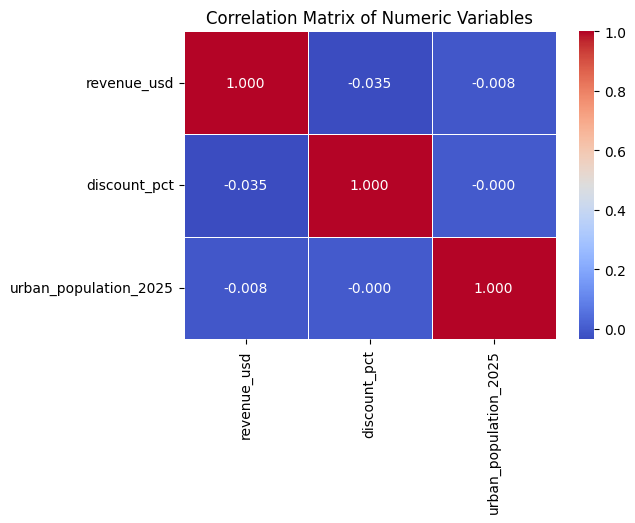

In [80]:
# Correlation matrix on numeric features
corr_matrix = train.select(["revenue_usd"] + num_features).toPandas().corr()
plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numeric Variables")
plt.show()

In [81]:
# VIF on numeric features
train_num_pd = train.select(num_features).toPandas()

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# add intercept
X = add_constant(train_num_pd)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                 feature       VIF
0                  const  1.900398
1           discount_pct  1.000000
2  urban_population_2025  1.000000


The VIF results show that both `discount_pct` and `urban_population_2025` have VIF values of 1.00, indicating that no multicollinearity exist between these numeric features. Ultimately, since all VIF values are below the general threshold of 5, we can conlcude that multicollinearity is not a concern in this model and these variables are retained for the regression analysis.

### ***6.6 Fitting the model on train and evaluating predictive performance***

In [82]:
model_raw = pipeline_raw.fit(train)
pred_raw_train = model_raw.transform(train)

26/03/19 21:03:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/19 21:03:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/19 21:03:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [83]:
# Define predictive performance metrics on model for linear regression
from pyspark.ml.evaluation import RegressionEvaluator

r2_eval = RegressionEvaluator(
    labelCol="revenue_usd",
    predictionCol="pred_raw",
    metricName="r2"
)

rmse_eval = RegressionEvaluator(
    labelCol="revenue_usd",
    predictionCol="pred_raw",
    metricName="rmse"
)

mae_eval = RegressionEvaluator(
    labelCol="revenue_usd",
    predictionCol="pred_raw",
    metricName="mae"
)

In [84]:
# Evaluate predictive performance on Train
print("RAW TARGET MODEL - Train")
print(f"Train R2   : {r2_eval.evaluate(pred_raw_train):.4f}")
print(f"Train RMSE : {rmse_eval.evaluate(pred_raw_train):.2f}")
print(f"Train MAE  : {mae_eval.evaluate(pred_raw_train):.2f}")

RAW TARGET MODEL - Train
Train R2   : 0.2365
Train RMSE : 2489.56
Train MAE  : 1061.89


<Figure size 800x500 with 0 Axes>

<Axes: xlabel='revenue_usd', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Revenue (Target Variable)')

Text(0.5, 0, 'Revenue (USD)')

Text(0, 0.5, 'Frequency')

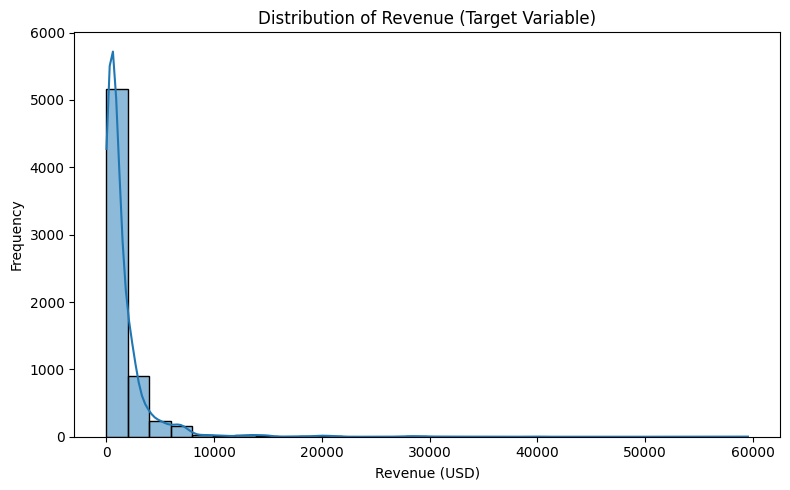

In [85]:
# Check distribution of target variable
target_pd = train.select("revenue_usd").toPandas()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(target_pd["revenue_usd"], bins=30, kde=True)

plt.title("Distribution of Revenue (Target Variable)")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

As seen in the above graph, the distribution of the target variable (`revenue_usd`) is right-skewed. To address this skewness and stabilise variance, a log transformation is applied to the target variable to improve model performnace.

### ***6.7 Applying log transformation on target variable***

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='revenue_usd', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Log Revenue (Transformed Target Variable)')

Text(0.5, 0, 'Log Revenue')

Text(0, 0.5, 'Frequency')

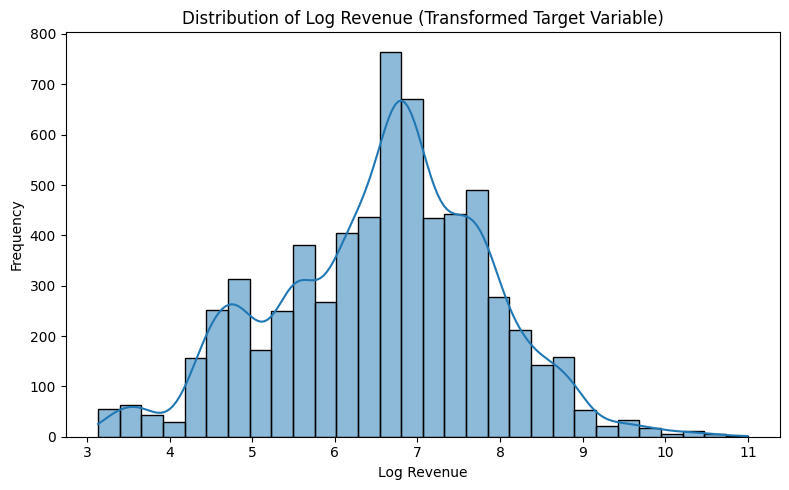

In [86]:
# Check distribution of log transformation on target variable
plt.figure(figsize=(8,5))
sns.histplot(np.log(target_pd["revenue_usd"]), bins=30, kde=True)

plt.title("Distribution of Log Revenue (Transformed Target Variable)")
plt.xlabel("Log Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The above graph confirms that applying a log transformation to the target variable (`revenue_usd`) results in a more symmetric distribution that more closely resembles a normal distribution. The transformation reduces the influence of extreme values and helps stabilise variance, making the data more suitable for linear regression modelling.

In [87]:
train_log = train.withColumn("log_revenue", F.log1p(F.col("revenue_usd")))
test_log = test.withColumn("log_revenue", F.log1p(F.col("revenue_usd")))
reserved_log = reserved.withColumn("log_revenue", F.log1p(F.col("revenue_usd")))

In [88]:
# Create log model
lr_log = LinearRegression(
    featuresCol="features",
    labelCol="log_revenue",
    predictionCol="log_pred",
    elasticNetParam=0.0,
    regParam=0.1,
    maxIter=200)

pipeline_log = Pipeline(stages=indexers + [encoder, assembler, scaler, lr_log])

model_log = pipeline_log.fit(train_log)
pred_log_train = model_log.transform(train_log)

In [89]:
# Define predictive performance metrics on log model for linear regression
from pyspark.ml.evaluation import RegressionEvaluator
r2_log = RegressionEvaluator(
    labelCol="log_revenue",
    predictionCol="log_pred",
    metricName="r2"
)

rmse_log = RegressionEvaluator(
    labelCol="log_revenue",
    predictionCol="log_pred",
    metricName="rmse"
)

mae_log = RegressionEvaluator(
    labelCol="log_revenue",
    predictionCol="log_pred",
    metricName="mae"
)

In [90]:
# Evaluate predictive performance on train
print("LOG TARGET MODEL (LOG SCALE) - Train")
print(f"Train R2   : {r2_log.evaluate(pred_log_train):.4f}")
print(f"Train RMSE : {rmse_log.evaluate(pred_log_train):.4f}")
print(f"Train MAE  : {mae_log.evaluate(pred_log_train):.4f}")

LOG TARGET MODEL (LOG SCALE) - Train
Train R2   : 0.6401
Train RMSE : 0.7643
Train MAE  : 0.6212


Evaluating the model performance, the log model results in an R² of 0.64, indicating that the model is able to explain 64% of the variance. The improvement in R² and decrease in error metrics suggest that the predictive performance of the model has improved.

In [91]:
# Apply back-transformation
pred_log_train_bt = pred_log_train.withColumn("pred_revenue",
                                              F.expm1(F.col("log_pred")))

In [92]:
# Evaluate predictive performance on train (original scale)
r2_orig = RegressionEvaluator(
    labelCol="revenue_usd",
    predictionCol="pred_revenue",
    metricName="r2"
)

rmse_orig = RegressionEvaluator(
    labelCol="revenue_usd",
    predictionCol="pred_revenue",
    metricName="rmse"
)

mae_orig = RegressionEvaluator(
    labelCol="revenue_usd",
    predictionCol="pred_revenue",
    metricName="mae"
)

print("LOG TARGET MODEL (ORIGINAL SCALE) - Train")
print(f"Train R2   : {r2_orig.evaluate(pred_log_train_bt):.4f}")
print(f"Train RMSE : {rmse_orig.evaluate(pred_log_train_bt):.2f}")
print(f"Train MAE  : {mae_orig.evaluate(pred_log_train_bt):.2f}")

LOG TARGET MODEL (ORIGINAL SCALE) - Train
Train R2   : 0.1580
Train RMSE : 2614.52
Train MAE  : 931.55


When predictions are transformed back to the original revenue scale, the R² value decreases compared to the log-scale model. This occurs because the regression model was trained to minimise errors in the log-transformed space, which emphasizes relative (percentage) differences rather than absolute dollar differences. When predictions are converted back to the original scale, larger revenue values contribute more heavily to the error metrics, which leads to a lower R² despite the model capturing the overall relationship well.

**Despite this reduction in R² after back-transformation, the log-transformed model remains appropriate because it better addresses the strong right-skewness of the target variable and stabilizes variance. Therefore, the log model is chosen for subsequent analysis and interpretation.**

### ***6.8 Evaluating on test***

In [93]:
pred_log_test = model_log.transform(test_log).withColumn(
    "pred_revenue",
    F.expm1(F.col("log_pred")))

In [94]:
print("LOG TARGET MODEL (LOG SCALE) - Test")
print(f"Test R2   : {r2_log.evaluate(pred_log_test):.4f}")
print(f"Test RMSE : {rmse_log.evaluate(pred_log_test):.4f}")
print(f"Test MAE  : {mae_log.evaluate(pred_log_test):.4f}")

LOG TARGET MODEL (LOG SCALE) - Test
Test R2   : 0.6205
Test RMSE : 0.7928
Test MAE  : 0.6365


### ***6.9 Evaluating on reserved***

In [95]:
pred_log_reserved = model_log.transform(reserved_log).withColumn(
    "pred_revenue",
    F.expm1(F.col("log_pred")))

In [96]:
print("LOG TARGET MODEL (LOG SCALE) - Reserved")
print(f"Reserved R2   : {r2_log.evaluate(pred_log_reserved):.4f}")
print(f"Reserved RMSE : {rmse_log.evaluate(pred_log_reserved):.4f}")
print(f"Reserved MAE  : {mae_log.evaluate(pred_log_reserved):.4f}")

LOG TARGET MODEL (LOG SCALE) - Reserved
Reserved R2   : 0.6193
Reserved RMSE : 0.7688
Reserved MAE  : 0.6255


### ***6.10 Combined results of linear regression model***

In [97]:
results_lr = {
    "Metric": ["R2", "RMSE", "MAE"],
    "Train": [
        r2_log.evaluate(pred_log_train),
        rmse_log.evaluate(pred_log_train),
        mae_log.evaluate(pred_log_train)
    ],
    "Test": [
        r2_log.evaluate(pred_log_test),
        rmse_log.evaluate(pred_log_test),
        mae_log.evaluate(pred_log_test)
    ],
    "Reserved": [
        r2_log.evaluate(pred_log_reserved),
        rmse_log.evaluate(pred_log_reserved),
        mae_log.evaluate(pred_log_reserved)
    ]
}

df_results_lr = pd.DataFrame(results_lr)

df_results_lr["Test vs Train"] = df_results_lr["Test"] - df_results_lr["Train"]
df_results_lr["Reserved vs Train"] = df_results_lr["Reserved"] - df_results_lr["Train"]

df_results_lr

,Metric,Train,Test,Reserved,Test vs Train,Reserved vs Train
0,R2,0.640094,0.620453,0.619299,-0.019641,-0.020795
1,RMSE,0.764302,0.792830,0.768775,0.028528,0.004472
2,MAE,0.621215,0.636458,0.625477,0.015244,0.004263


Comparing the predictive performance metrics across the Train, Test, Reserved datasets, minimal differences in R², RMSE and MAE are observed, therefore indicating that the model generalises well and shows no significant signs of overfitting.

## **7. Building the Machine Learning Model - Option 2: Random Forest**

While the linear regression model demonstrates stable performance, it assumes a linear relationship between the predictors and the target variable. To explore whether a more flexible model is able to better capture potential non-linear relationships, Random Forest is implemented.

In [98]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="log_revenue",
    predictionCol="rf_pred",
    numTrees=200,
    maxDepth=6)

pipeline_rf = Pipeline(stages=indexers + [encoder, assembler, scaler, rf])

model_rf = pipeline_rf.fit(train_log)

26/03/19 21:04:21 WARN DAGScheduler: Broadcasting large task binary with size 1238.4 KiB
26/03/19 21:04:21 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


In [99]:
pred_rf_train = model_rf.transform(train_log)
pred_rf_test = model_rf.transform(test_log)
pred_rf_reserved = model_rf.transform(reserved_log)

In [100]:
r2_rf = RegressionEvaluator(
    labelCol="log_revenue",
    predictionCol="rf_pred",
    metricName="r2"
)

rmse_rf = RegressionEvaluator(
    labelCol="log_revenue",
    predictionCol="rf_pred",
    metricName="rmse"
)

mae_rf = RegressionEvaluator(
    labelCol="log_revenue",
    predictionCol="rf_pred",
    metricName="mae"
)

In [101]:
results_rf = {
    "Metric": ["R2", "RMSE", "MAE"],
    "Train": [
        r2_rf.evaluate(pred_rf_train),
        rmse_rf.evaluate(pred_rf_train),
        mae_rf.evaluate(pred_rf_train)
    ],
    "Test": [
        r2_rf.evaluate(pred_rf_test),
        rmse_rf.evaluate(pred_rf_test),
        mae_rf.evaluate(pred_rf_test)
    ],
    "Reserved": [
        r2_rf.evaluate(pred_rf_reserved),
        rmse_rf.evaluate(pred_rf_reserved),
        mae_rf.evaluate(pred_rf_reserved)
    ]
}

df_results_rf = pd.DataFrame(results_rf)

df_results_rf["Test vs Train"] = df_results_rf["Test"] - df_results_rf["Train"]
df_results_rf["Reserved vs Train"] = df_results_rf["Reserved"] - df_results_rf["Train"]

df_results_rf

,Metric,Train,Test,Reserved,Test vs Train,Reserved vs Train
0,R2,0.656755,0.620441,0.620638,-0.036314,-0.036117
1,RMSE,0.746401,0.792842,0.767421,0.046441,0.021020
2,MAE,0.607647,0.636571,0.623171,0.028924,0.015524


## **8. Comparing Machine Learning Models - Linear Regression vs Random Forest**

In [102]:
df_lr = df_results_lr.rename(columns={
    "Train": "LR Train",
    "Test": "LR Test",
    "Reserved": "LR Reserved",
    "Test vs Train": "LR Test vs Train",
    "Reserved vs Train": "LR Reserved vs Train"
})

df_rf = df_results_rf.rename(columns={
    "Train": "RF Train",
    "Test": "RF Test",
    "Reserved": "RF Reserved",
    "Test vs Train": "RF Test vs Train",
    "Reserved vs Train": "RF Reserved vs Train"
})

df_compare = df_lr.merge(df_rf, on="Metric")

def highlight_models(col):
    if "LR" in col.name:
        return ["background-color: #d5f5e3"] * len(col)   # light green
    elif "RF" in col.name:
        return ["background-color: #fadbd8"] * len(col)   # light red
    else:
        return [""] * len(col)

df_compare.style \
    .format(precision=4) \
    .apply(highlight_models, axis=0)

,Metric,LR Train,LR Test,LR Reserved,LR Test vs Train,LR Reserved vs Train,RF Train,RF Test,RF Reserved,RF Test vs Train,RF Reserved vs Train
0,R2,0.6401,0.6205,0.6193,-0.0196,-0.0208,0.6568,0.6204,0.6206,-0.0363,-0.0361
1,RMSE,0.7643,0.7928,0.7688,0.0285,0.0045,0.7464,0.7928,0.7674,0.0464,0.0210
2,MAE,0.6212,0.6365,0.6255,0.0152,0.0043,0.6076,0.6366,0.6232,0.0289,0.0155


From the overall predictive performance results above, although Random Forest has the ability to model complex non-linear relationships, the Linear Regression model demonstrates slightly better predictive performance and greater stability across the datasets. Therefore, Linear Regression is selected as the preferred model for this analysis.

## **9. Combining all analyses**

This analysis combines Spark-based machine learning (for driver identification) with descriptive market analysis (for channel and growth strategy).

### ***9.1 Evaluating features importance***

In [103]:
# Access final stage in pipeline and coefficients
lr_model = model_log.stages[-1]
coefficients = lr_model.coefficients.toArray()

In [104]:
# Metadata from the assembled raw feature vector
meta = pred_log_train.schema["features_raw"].metadata

# Extract feature information from metadata
feature_info = []
for attr_type in meta["ml_attr"]["attrs"]:
    feature_info.extend(meta["ml_attr"]["attrs"][attr_type])

feature_info = sorted(feature_info, key=lambda x: x["idx"])

feature_names = [x["name"] for x in feature_info]

print("Number of feature names:", len(feature_names))

Number of feature names: 31


In [105]:
# Build coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df = coef_df.reset_index(drop=True)

def color_sign(val):
    if val > 0:
        return "color: green"
    elif val < 0:
        return "color: red"
    else:
        return ""

coef_df.style \
    .format({
        "Coefficient": "{:.4f}",
        "Abs_Coefficient": "{:.4f}"
    }) \
    .applymap(color_sign, subset=["Coefficient"]) \
    .background_gradient(subset=["Abs_Coefficient"], cmap="RdYlGn")

/tmp/ipykernel_3419/3732662774.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_sign, subset=["Coefficient"]) \


,Feature,Coefficient,Abs_Coefficient
0,category_ohe_Accessories,-0.6239,0.6239
1,category_ohe_Mac,0.4623,0.4623
2,category_ohe_iPhone,0.2710,0.2710
3,category_ohe_AirPods,-0.1901,0.1901
4,category_ohe_iPad,0.1139,0.1139
5,discount_pct,-0.0460,0.0460
6,category_ohe_Apple Watch,-0.0387,0.0387
7,sales_channel_ohe_Corporate / B2B,-0.0164,0.0164
8,sales_channel_ohe_Authorized Reseller,0.0122,0.0122
9,customer_age_group_ohe_18–24,-0.0122,0.0122


**Key Insights:**
1. Product mix is the main predictor of revenue variation
2. Higher discounts are associated with lower predicted revenue
3. Consumer retail channels perform better than enterprise channels

### ***9.2 Combining with earlier Apple insights***

In [106]:
# Extracting top 3 countries in terms of revenue and volume
top3 = df_rank.head(3)
top3

,country,overall_rank,urban_population_2025,avg_rev,avg_units,rev_per_1000_urban,rank_rev_urban,units_per_million_urban,rank_units_urban,combined_score
0,IRELAND,1,3296292,102399.20,159.67,31.06,2,48.44,1,3
1,NEW ZEALAND,2,4390587,142538.96,163.00,32.46,1,37.12,3,4
2,FINLAND,3,4875426,131035.65,185.67,26.88,4,38.08,2,6


In [107]:
# Extracting bottom 3 countries in terms of revenue and volume
bottom3 = df_rank.tail(3)
bottom3

,country,overall_rank,urban_population_2025,avg_rev,avg_units,rev_per_1000_urban,rank_rev_urban,units_per_million_urban,rank_units_urban,combined_score
44,UNITED STATES,40,287544368,93519.50,147.00,0.33,45,0.51,44,89
45,INDIA,41,543094109,131541.51,144.33,0.24,46,0.27,45,91
46,CHINA,42,955864863,113281.60,158.00,0.12,47,0.17,46,93


In [108]:
# Combined table for top 3 and bottom 3
top3 = df_rank.head(3).copy()
bottom3 = df_rank.tail(3).copy()

top3["group"] = "Top 3"
bottom3["group"] = "Bottom 3"

combined_top3_bottom3 = pd.concat([top3, bottom3]).reset_index(drop=True)

cols = combined_top3_bottom3.columns.tolist()
cols.remove("group")
cols.insert(1, "group")
combined_top3_bottom3 = combined_top3_bottom3[cols]

def color_country(row):
    if row["group"] == "Top 3":
        return ["color: green"] + [""] * (len(row) - 1)
    else:
        return ["color: red"] + [""] * (len(row) - 1)

format_dict = {
    "urban_population_2025": "{:.0f}",
    "avg_rev": "{:.2f}",
    "avg_units": "{:.2f}",
    "rev_per_1000_urban": "{:.2f}",
    "units_per_million_urban": "{:.2f}"
}

combined_top3_bottom3.style \
    .apply(color_country, axis=1) \
    .format(format_dict)

,country,group,overall_rank,urban_population_2025,avg_rev,avg_units,rev_per_1000_urban,rank_rev_urban,units_per_million_urban,rank_units_urban,combined_score
0,IRELAND,Top 3,1,3296292,102399.20,159.67,31.06,2,48.44,1,3
1,NEW ZEALAND,Top 3,2,4390587,142538.96,163.00,32.46,1,37.12,3,4
2,FINLAND,Top 3,3,4875426,131035.65,185.67,26.88,4,38.08,2,6
3,UNITED STATES,Bottom 3,40,287544368,93519.50,147.00,0.33,45,0.51,44,89
4,INDIA,Bottom 3,41,543094109,131541.51,144.33,0.24,46,0.27,45,91
5,CHINA,Bottom 3,42,955864863,113281.60,158.00,0.12,47,0.17,46,93


In [109]:
# Extract country, group
country_group = combined_top3_bottom3[["country", "group"]]

In [110]:
# Check product mix for Top 3 and Bottom 3
combined_product_mix = country_group.merge(
    df_product,
    on="country",
    how="left"
)

product_mix_cols = ["Accessories", "AirPods", "Apple Watch", "Mac", "iPad", "iPhone"]

combined_product_mix.style \
    .apply(color_country, axis=1) \
    .format({col: "{:.2%}" for col in mix_cols}) \
    .background_gradient(subset=product_mix_cols, cmap="Blues", axis=1)

,country,group,Accessories,AirPods,Apple Watch,Mac,iPad,iPhone
0,IRELAND,Top 3,4.17%,4.00%,5.21%,35.78%,16.16%,34.70%
1,NEW ZEALAND,Top 3,2.44%,2.26%,6.18%,50.09%,9.67%,29.35%
2,FINLAND,Top 3,2.83%,4.23%,5.01%,37.66%,15.02%,35.25%
3,UNITED STATES,Bottom 3,4.13%,2.63%,4.11%,35.68%,11.82%,41.63%
4,INDIA,Bottom 3,1.63%,3.09%,5.74%,49.14%,10.32%,30.08%
5,CHINA,Bottom 3,3.37%,3.25%,4.79%,43.12%,8.98%,36.49%


In [111]:
# Check channel mix for Top 3 and Bottom 3
# Extract country + group
country_group = combined_top3_bottom3[["country", "group"]]

# Merge with channel mix table
combined_channel_mix = country_group.merge(
    df_channel,
    on="country",
    how="left"
)

channel_cols = [c for c in combined_channel_mix.columns if c not in ["country", "group"]]

combined_channel_mix.style \
    .apply(color_country, axis=1) \
    .format({col: "{:.2%}" for col in channel_cols}) \
    .background_gradient(subset=channel_cols, cmap="Blues", axis=1)

,country,group,Apple Store,Authorized Reseller,Carrier Store,Corporate / B2B,Online (Apple.com),Third-Party Retailer
0,IRELAND,Top 3,17.17%,15.98%,18.37%,23.88%,11.23%,13.37%
1,NEW ZEALAND,Top 3,10.79%,21.08%,20.26%,12.05%,17.24%,18.59%
2,FINLAND,Top 3,13.43%,12.78%,20.34%,14.88%,17.55%,21.02%
3,UNITED STATES,Bottom 3,13.21%,17.20%,14.91%,14.39%,21.05%,19.25%
4,INDIA,Bottom 3,11.60%,13.97%,34.31%,12.59%,14.56%,12.96%
5,CHINA,Bottom 3,14.16%,12.04%,25.71%,14.32%,11.68%,22.10%


## **10. Conclusion: Connecting all the dots**

### ***10.1 Answering Business Question 1: Which Apple products should be prioritised to drive revenue?***

As shown in the feature importance analysis in **`Part 9.1`**, product category is the strongest driver of revenue variation, with Accessories (0.62), Mac (0.46) and iPhone (0.27) showing the largest absolute coefficients. High-value devices such as Mac and iPhone should be prioritised as they generate higher transaction value, while accessories should be leveraged to support ecosystem adoption and increase basket size.

<Figure size 800x600 with 0 Axes>

Text(0.6339356622319803, 0, '0.624')

Text(0.47229714118040006, 1, '0.462')

Text(0.2810385513103475, 2, '0.271')

Text(0.20009996981946504, 3, '0.190')

...

Text(0.022170967041137985, 8, '0.012')

Text(0.022164354773073536, 9, '0.012')

Text(0.5, 1.0, 'Top 10 Feature Importance (Linear Regression)')

Text(0.5, 0, 'Absolute Coefficient')

Text(0, 0.5, 'Feature')

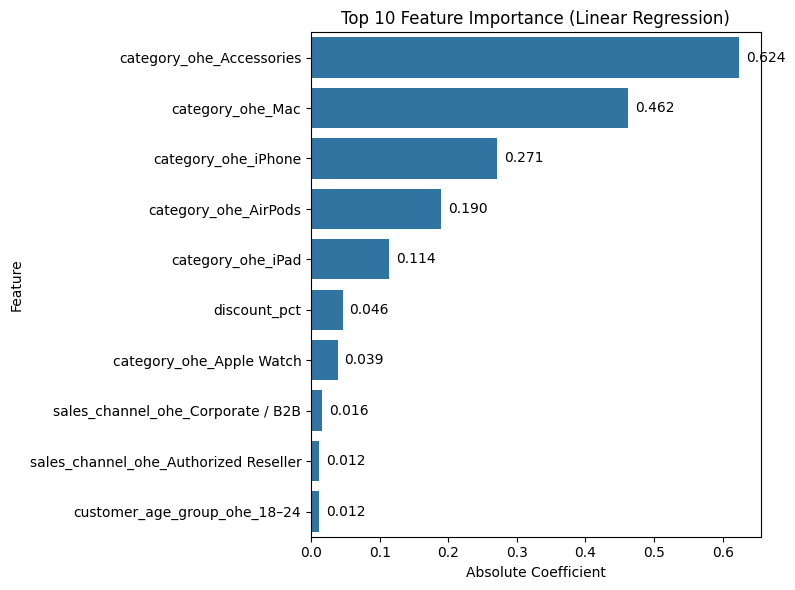

In [112]:
# Plot feature importance
top_features = coef_df.head(10)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=top_features,
    x="Abs_Coefficient",
    y="Feature"
)

for i, v in enumerate(top_features["Abs_Coefficient"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.title("Top 10 Feature Importance (Linear Regression)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### ***10.2 Answering Business Question 2: What sales channel strategy is more effective across different markets?***

The channel mix comparison between the top 3 and bottom 3 markets in **`Part 9.2`** show clear differences in distribution strategy. Top-performing markets such as Ireland, New Zealand, and Finland rely more on Apple ecosystem channels (Apple Store and authorised resellers), enabling stronger control over customer experience. In contrast, underperforming markets such as India and China depend more on carrier stores and third-party retailers, with carrier channels accounting for a significant share of revenue.

This suggests that Apple should strengthen direct ecosystem channels in mature markets, while leveraging carrier partnerships to expand reach in emerging markets.

### ***10.3 Answering Business Question 3: Which markets present greater growth opportunities for Apple?***

The ranking of countries by revenue and units relative to urban population in **`df_rank`** of **`Part 5.2`** highlights differences in market maturity and growth potential.

Mature markets such as Ireland, New Zealand, and Finland show high revenue per urban consumer, indicating strong Apple adoption. In contrast, large markets such as China, India, and the United States exhibit much lower revenue per urban population despite having very large population size. This suggests that large underpenetrated markets, particularly China and India, present the greatest growth opportunities, where expanding ecosystem adoption and strengthening distribution channels can drive significant revenue growth.

In [113]:
# Extract urban metrics for Top 3 and Bottom 3 countries
urban_metrics_top_bottom = (
    df_combined
    .select(
        "country",
        "urban_population_rate_2025",
        "urban_population_2025",
        "population_2025"
    )
    .dropDuplicates(["country"])
    .toPandas()
    .merge(country_group, on="country", how="inner")
)

# Reorder columns
urban_metrics_top_bottom = urban_metrics_top_bottom[
    [
        "country",
        "group",
        "urban_population_rate_2025",
        "urban_population_2025",
        "population_2025"
    ]
]

# Sort by urban population rate
urban_metrics_top_bottom = urban_metrics_top_bottom.sort_values(
    "urban_population_rate_2025",
    ascending=True
)

# Style for display
urban_metrics_top_bottom.style \
    .apply(color_country, axis=1) \
    .format({
        "urban_population_rate_2025": "{:.2%}",
        "urban_population_2025": "{:,.0f}",
        "population_2025": "{:,.0f}"
    }) \
    .background_gradient(subset=["urban_population_rate_2025"], cmap="Blues")

,country,group,urban_population_rate_2025,urban_population_2025,population_2025
3,INDIA,Bottom 3,37.10%,"543,094,109","1,463,865,525"
4,IRELAND,Top 3,62.10%,"3,296,292","5,308,039"
0,CHINA,Bottom 3,67.50%,"955,864,863","1,416,096,094"
5,UNITED STATES,Bottom 3,82.80%,"287,544,368","347,275,807"
2,NEW ZEALAND,Top 3,83.60%,"4,390,587","5,251,899"
1,FINLAND,Top 3,86.70%,"4,875,426","5,623,329"


### ***10.4 Final recommendations***

**1. Expand Ecosystem Adoption in Underperforming Markets**  
- High-value devices (Mac, iPhone) drive transaction revenue)
- Top markets show more balanced product mix vs underperforming markets
- Expand ecosystem bundles (e.g. Mac + iPad) to increase basket size and customer lifetime value

**2. Strengthen Apple Ecosystem Channels**  
- Top markets rely more on Apple ecosystem channels (Apple Store, authorised resllers)
- Underperforming markets depend more on carrrier and third-party channels
- Invest in Apple retail and online channels, while maintaining partners to optimise reach and experience

**3. Capture Growth in Large Underpenetrated Markets with Phased Expansion Strategy**  
- India and china show low revenue per urban consumer and significant untapped demand
- Adopt a phased strategy: Leverage carrier and retail partners in the short-term; Expand Apple-controlled channels in the long-term

### ***10.5 Limitations***

- **Synthetic dataset:** Apple sales data is synthetic and may not fully capture and reflect real-world market dynamics, consumer behaviour or competitive conditions.
- **Limited explanatory variables:** Model focuses mainly on product category and sales channel. However other factors such as pricing, income levels or marketing activities were not explored further. 
- **Aggregated country-level analysis:** Results and analysis were conducted on a country-level, hence variations across cities, regions or customer segments were not captured which may influence product adoption and channel effectiveness as well. 

### ***10.6 Next steps and possible further analysis***

- **Incorporate additional market indicators:** Include variables such as GDP per capita, income levels and pricing differences to better capture purchasing power and demand drivers.
- **Expand the dataset and time horizon:** Include analysis over time to analyse trends and improve robustness.
- **Conduct deeper market segmentation:** Analyse product and channel performance across regions, cities and customer segments to identify more tageted growth opportunities.

### ***10.7 Overall Conclusion***

Overall, the analysis indicates that Apple can achieve sustainable growth by implementing market-specific strategies that optimise both product mix and sales channel distribution.

We hope you have enjoyed our analysis and detailed walkthrough of our thought process and approach. :)